<a href="https://colab.research.google.com/github/nhat4589/BigData/blob/main/mo_hinh_goi_y.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================
# IMPORT LIBRARIES
# ==========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import warnings

warnings.filterwarnings("ignore")

# NLP
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import stopwords

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Evaluation
from sklearn.metrics import precision_score

print("Libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Libraries imported successfully!


In [ ]:
# ==========================
# READ DATA
# ==========================

user_df = pd.read_csv("user_data.csv")
cv_df = pd.read_csv("cv_data.csv")
job_df = pd.read_csv("job_data.csv")
app_df = pd.read_csv("applications.csv")

print("User Shape :", user_df.shape)
print("CV Shape   :", cv_df.shape)
print("Job Shape  :", job_df.shape)
print("App Shape  :", app_df.shape)

User Shape : (3191, 12)
CV Shape   : (3983, 805)
Job Shape  : (14634, 789)
App Shape  : (3983, 22)


In [ ]:
print("========== USER ==========")
display(user_df.head())

print("========== CV ==========")
display(cv_df.head())

print("========== JOB ==========")
display(job_df.head())

print("========== APPLICATION ==========")
display(app_df.head())

========== USER ==========


,UserID,User Name,Gender,Marriage,Age,URL User,crawled_email,crawled_phone,crawled_city,crawled_district,crawled_address,user_hash
0,382,Lê Trọng Quân,Nam,Đã có gia đình,36,https://timviec365.vn/ung-vien/le-trong-quan-u...,đăng nhập để xem email,đăng nhập để xem sdt,Hà Nội,NaN,Ngõ 189 - Cầu Diễn - Quận Bắc Từ Liêm,U_4f6ffe13
1,589,NguyỄn ThỊ Thu HƯỜng,Nữ,Đã có gia đình,32,https://timviec365.vn/ung-vien/nguyen-thi-thu-...,đăng nhập để xem email,đăng nhập để xem sdt,Bình Dương,Thị xã Bến Cát,"Đường N11, đối diện cổng KCN Mỹ phước 3",U_30bb3825
2,3469,VÕ ĐỨC NGUYÊN,Nam,Đã có gia đình,37,https://timviec365.vn/ung-vien/vo-duc-nguyen-u...,đăng nhập để xem email,đăng nhập để xem sdt,Vĩnh Long,Thành phố Vĩnh Long,Hồ Chí Minh,U_ca851e9f
3,7042,Nguyen Duy 1995,Nam,Độc thân,12,https://timviec365.vn/ung-vien/nguyen-duy-1995...,NaN,NaN,NaN,NaN,NaN,U_8c66bb19
4,9641,Trương Bình,Nam,Đã có gia đình,41,https://timviec365.vn/ung-vien/truong-binh-uv9...,đăng nhập để xem email,đăng nhập để xem sdt,Hồ Chí Minh,Quận Bình Thạnh,"304/21 Bùi Đình Túy, Phường 12, quận Bình Thạn...",U_39d4b545


========== CV ==========


,cv_id,URL User,UserID,User Name,Industry,Desired Job,Workplace Desired,Desired Salary,Gender,Marriage,...,emb_758,emb_759,emb_760,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767
0,0,https://timviec365.vn/ung-vien/nguyen-quan-uv9...,964496,Nguyễn Quân,Vận tải - Lái xe,Nhân viên lái xe bằng B2,Hà Nội,Thỏa thuận,Nam,Đã có gia đình,...,0.600825,0.511933,-0.208179,0.212074,0.061284,0.223628,0.019250,0.194453,-0.072175,0.425853
1,1,https://timviec365.vn/ung-vien/nguyen-chau-uv9...,986206,Nguyễn Châu,Vận tải - Lái xe,Nhân viên lái xe bằng D,Bình Dương,Thỏa thuận,Nam,Đã có gia đình,...,0.601157,0.557574,0.236482,0.101709,0.024328,0.359112,-0.218193,0.008860,-0.213983,-0.027345
2,2,https://timviec365.vn/ung-vien/la-thi-hoang-uv...,769632,LÃ THỊ HOÀNG,Hành chính - Văn phòng,"Nhân viên văn phòng, khu công nghiệp sử dụng t...",Bắc Giang,Thỏa thuận,Nữ,Độc thân,...,0.443752,0.322814,-0.239094,0.034862,0.151213,0.593769,-0.028457,0.110291,-0.511533,0.184295
3,3,https://timviec365.vn/ung-vien/nguyen-van-bao-...,981314,Nguyễn Văn Bảo,Vận tải - Lái xe,Nhân viên lái xe hạng C,Hà Nội,Thỏa thuận,Nam,Đã có gia đình,...,0.249631,0.704585,-0.183760,-0.036537,0.039875,0.383212,-0.060554,0.020498,0.057639,0.251092
4,4,https://timviec365.vn/ung-vien/nguyen-thi-tu-u...,962892,Nguyễn Thị Tứ,Quản lý đơn hàng,Nhân viên thu mua,Hồ Chí Minh,Thỏa thuận,Nữ,Độc thân,...,-0.686522,0.528227,-0.300178,0.138474,0.086171,0.361449,0.271444,-0.047408,-0.291347,0.283056


========== JOB ==========


,job_id,JobID,URL Job,Job Title,Name Company,Company Overview,Company Size,Company Address,Job Description,Job Requirements,...,emb_758,emb_759,emb_760,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767
0,0,0,https://www.topcv.vn/viec-lam/sale-admin-websi...,Sale Admin Website,Công ty Cổ phần Belie,DHC Việt Nam trực thuộc Công ty CP Belie – Nhà...,100-499,"HN: Tầng 9, Tòa IDMC Mỹ Đình, 18 Tôn Thất Thuy...",Thường xuyên cập nhật các thay đổi liên quan t...,"1. Học vấn, kiến thức và trình độ chuyên môn:T...",...,0.552519,0.544531,-0.324816,0.672734,-0.028778,0.220237,-0.027441,0.325495,-0.129809,0.457144
1,1,1,https://www.topcv.vn/viec-lam/thuc-tap-sinh-la...,"Thực Tập Sinh Lập Trình (No-Code, Low-Code Pla...",Công Ty Cổ Phần Global Online Branding,Thành viên thuộc Tập đoàn G-Group:Công ty Cổ p...,100-499,"Lầu 6, 235 Lý Thường Kiệt ,Phường 6 ,Quận Tân ...","Phối hợp với bộ phận lập trình No-code, Low-co...","Sinh viên năm 3, năm 4 hoặc sinh viên cao học ...",...,0.233406,-0.085451,-0.210707,0.326805,0.098101,0.230667,0.167121,0.160990,-0.220067,0.353418
2,2,2,https://www.topcv.vn/viec-lam/hr-business-part...,HR Business Partner,Công Ty Melody Logistics,Công Ty TNHH Melody Logistics được biết đến là...,100-499,"Số 01 Nguyễn Văn Đậu Phường 5, Quận Phú Nhuận,...",Xây dựng và thực hiện chiến lược nhân sự phù h...,Tốt nghiệp đại học các chuyên ngành liên quan ...,...,0.523179,0.113905,-0.283114,0.393307,-0.038226,0.397251,0.293141,0.410323,-0.593703,-0.215380
3,3,3,https://www.topcv.vn/viec-lam/general-manager/...,General Manager,CÔNG TY TNHH DV HOLDINGS,"Khách sạn Danaciti By Dabi là khách sạn 4 sao,...",25-99,"80 Đông Kinh Nghĩa Thục, Sơn Trà, Đà Nẵng",1. Lập và triển khai kế hoạch kinh doanh- Định...,- Tốt nghiệp đại học trở lên chuyên ngành quản...,...,0.790343,0.279657,-0.191990,0.551387,0.026877,0.491919,0.173503,0.227855,-0.312514,-0.018788
4,4,4,https://www.topcv.vn/viec-lam/le-tan-gymasaste...,Lễ Tân Gymasaster Quận 12,CÔNG TY TNHH TM XNK NGUỒN SỐNG VIỆT,Công ty TNHH TM XNK Nguồn Sống Việt cung câ...,100-499,"235 đường 9A, khu dân cư Trung Sơn, huyện Bi...",- Trực quầy Lễ tân- Tư vấn bán hàng gói member...,- Giới tính: Ưu tiên Nữ từ 22 - 35 tuổi- Kinh ...,...,0.116169,0.580710,-0.293779,0.531025,0.243370,0.385087,0.219741,0.206987,-0.360705,0.383754


========== APPLICATION ==========


,application_id,cv_id,job_0,dist_0,job_1,dist_1,job_2,dist_2,job_3,dist_3,...,job_5,dist_5,job_6,dist_6,job_7,dist_7,job_8,dist_8,job_9,dist_9
0,0,0,8768,0.0,3633,0.00,3981,0.00,13370,0.00,...,11622,0.00,3852,0.00,7219,0.00,4985,607.65,6828,607.65
1,1,1,13259,0.0,13985,23.25,13119,23.25,10869,23.25,...,12170,23.25,3633,1120.62,13370,1120.62,12961,1120.62,13248,1120.62
2,2,2,12340,NaN,6587,NaN,2304,NaN,13712,NaN,...,10561,NaN,12594,NaN,1005,NaN,1291,NaN,8813,NaN
3,3,3,3633,0.0,8768,0.00,13370,0.00,11891,0.00,...,8707,0.00,10068,70.96,6828,607.65,4985,607.65,13985,1143.60
4,4,4,2146,0.0,13652,0.00,6004,0.00,12136,0.00,...,14288,0.00,2077,55.84,10124,55.84,14237,1139.22,3409,1143.60


In [ ]:
print("===== USER INFO =====")
user_df.info()

print("\n===== CV INFO =====")
cv_df.info()

print("\n===== JOB INFO =====")
job_df.info()

print("\n===== APPLICATION INFO =====")
app_df.info()

===== USER INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3191 entries, 0 to 3190
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   UserID            3191 non-null   int64 
 1   User Name         3191 non-null   object
 2   Gender            3191 non-null   object
 3   Marriage          3191 non-null   object
 4   Age               3191 non-null   int64 
 5   URL User          3191 non-null   object
 6   crawled_email     2645 non-null   object
 7   crawled_phone     2645 non-null   object
 8   crawled_city      2632 non-null   object
 9   crawled_district  2517 non-null   object
 10  crawled_address   2644 non-null   object
 11  user_hash         3191 non-null   object
dtypes: int64(2), object(10)
memory usage: 299.3+ KB

===== CV INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3983 entries, 0 to 3982
Columns: 805 entries, cv_id to emb_767
dtypes: bool(1), float64(775), int64(4),

In [ ]:
print("========== Missing Values ==========\n")

print("User")
display(user_df.isnull().sum())

print("\nCV")
display(cv_df.isnull().sum())

print("\nJob")
display(job_df.isnull().sum())

print("\nApplication")
display(app_df.isnull().sum())

========== Missing Values ==========

User


,0
UserID,0
User Name,0
Gender,0
Marriage,0
Age,0
URL User,0
crawled_email,546
crawled_phone,546
crawled_city,559
crawled_district,674



CV


,0
cv_id,0
URL User,0
UserID,0
User Name,0
Industry,0
...,...
emb_763,0
emb_764,0
emb_765,0
emb_766,0



Job


,0
job_id,0
JobID,0
URL Job,0
Job Title,0
Name Company,0
...,...
emb_763,0
emb_764,0
emb_765,0
emb_766,0



Application


,0
application_id,0
cv_id,0
job_0,0
dist_0,697
job_1,0
dist_1,697
job_2,0
dist_2,697
job_3,0
dist_3,697


In [ ]:
print("Duplicate User :", user_df.duplicated().sum())
print("Duplicate CV :", cv_df.duplicated().sum())
print("Duplicate Job :", job_df.duplicated().sum())
print("Duplicate App :", app_df.duplicated().sum())

Duplicate User : 0
Duplicate CV : 0
Duplicate Job : 0
Duplicate App : 0


In [ ]:
display(user_df.describe(include='all'))

,UserID,User Name,Gender,Marriage,Age,URL User,crawled_email,crawled_phone,crawled_city,crawled_district,crawled_address,user_hash
count,3191.000000,3191,3191,3191,3191.000000,3191,2645,2645,2632,2517,2644,3191
unique,NaN,2870,3,3,NaN,3191,1,1,63,446,1769,3191
top,NaN,Nguyễn Cường,Nam,Đã có gia đình,NaN,https://timviec365.vn/ung-vien/nguyen-phuong-a...,đăng nhập để xem email,đăng nhập để xem sdt,Hồ Chí Minh,Thành phố Thủ Đức,"Thành phố Thủ Đức, TP Hồ Chí Minh",U_8daace64
freq,NaN,9,2354,1897,NaN,1,2645,2645,842,106,41,1
mean,938641.831087,NaN,NaN,NaN,30.755876,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,139315.564156,NaN,NaN,NaN,9.716496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,382.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,962147.500000,NaN,NaN,NaN,24.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,972981.000000,NaN,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,984026.000000,NaN,NaN,NaN,37.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


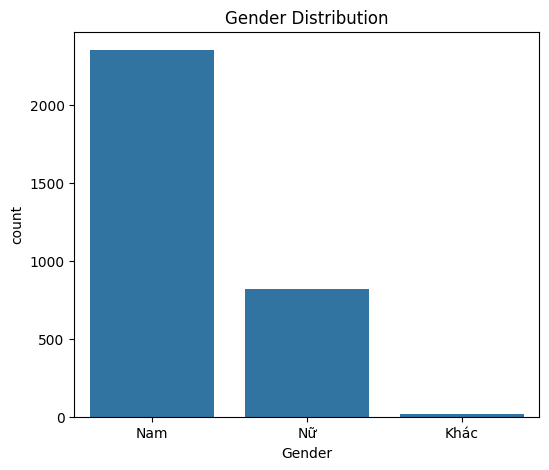

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(data=user_df,
              x='Gender')

plt.title("Gender Distribution")
plt.show()

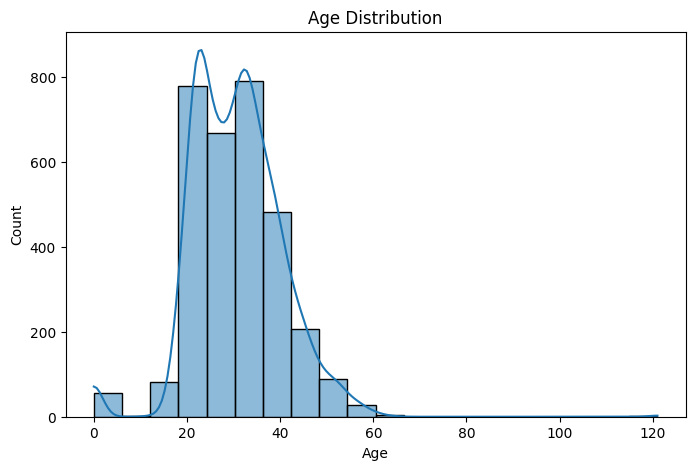

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(user_df["Age"],
             bins=20,
             kde=True)

plt.title("Age Distribution")

plt.show()

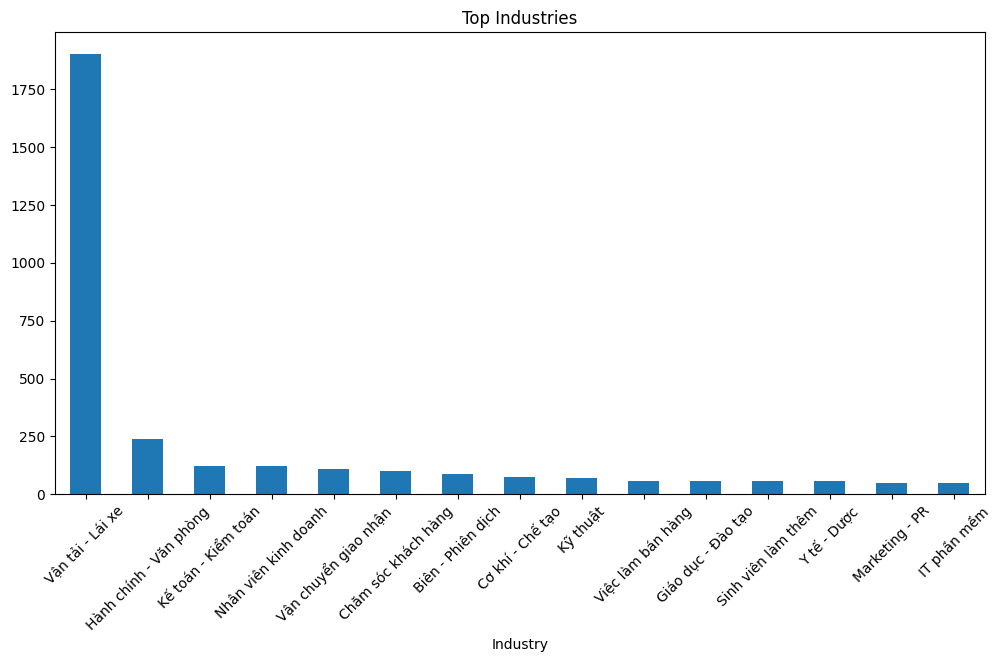

In [ ]:
plt.figure(figsize=(12,6))

cv_df["Industry"].value_counts().head(15).plot(kind="bar")

plt.title("Top Industries")

plt.xticks(rotation=45)

plt.show()

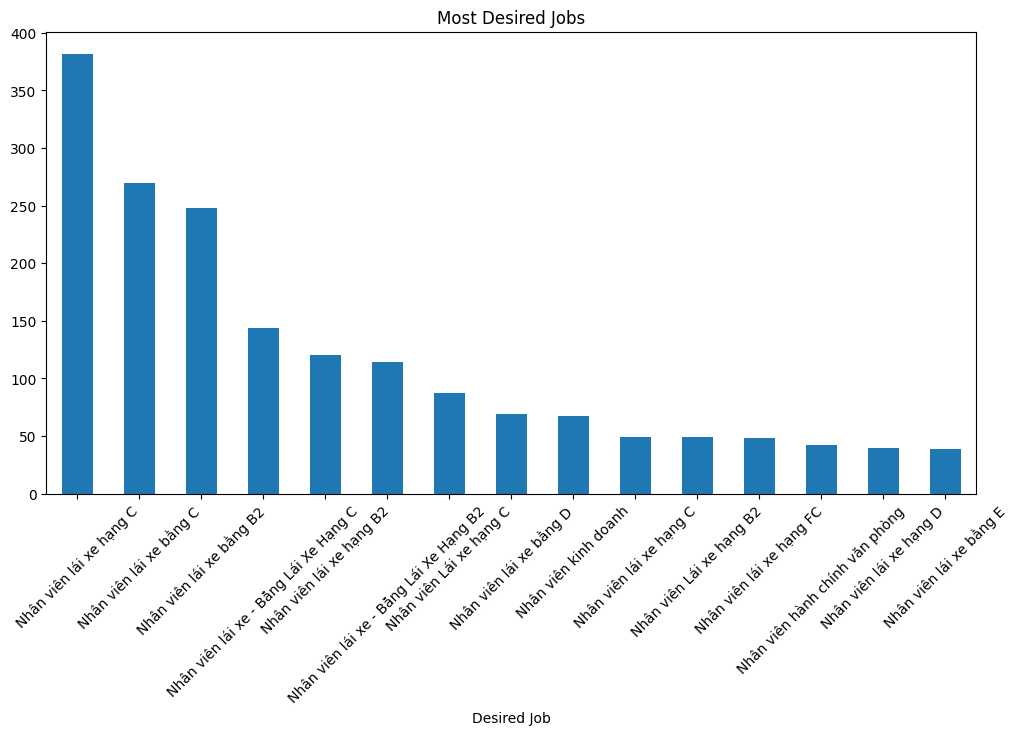

In [ ]:
plt.figure(figsize=(12,6))

cv_df["Desired Job"].value_counts().head(15).plot(kind="bar")

plt.title("Most Desired Jobs")

plt.xticks(rotation=45)

plt.show()

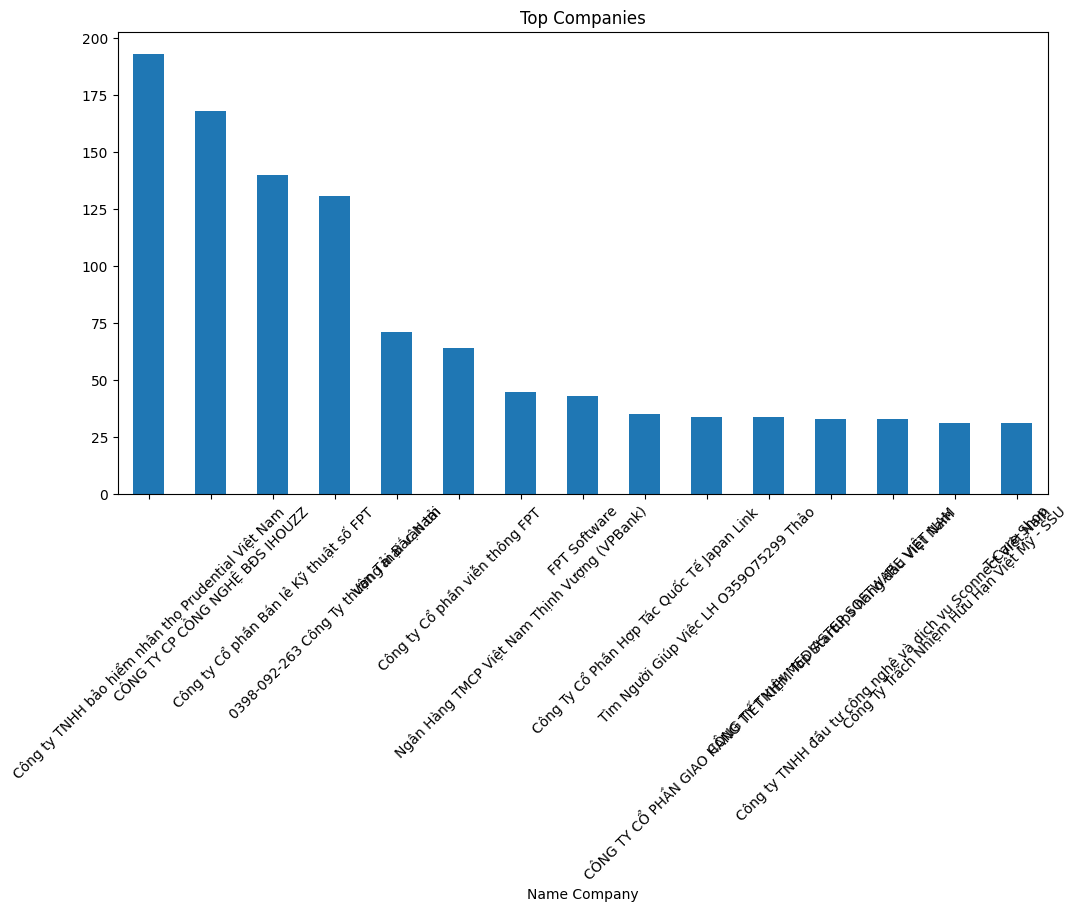

In [ ]:
plt.figure(figsize=(12,6))

job_df["Name Company"].value_counts().head(15).plot(kind="bar")

plt.title("Top Companies")

plt.xticks(rotation=45)

plt.show()

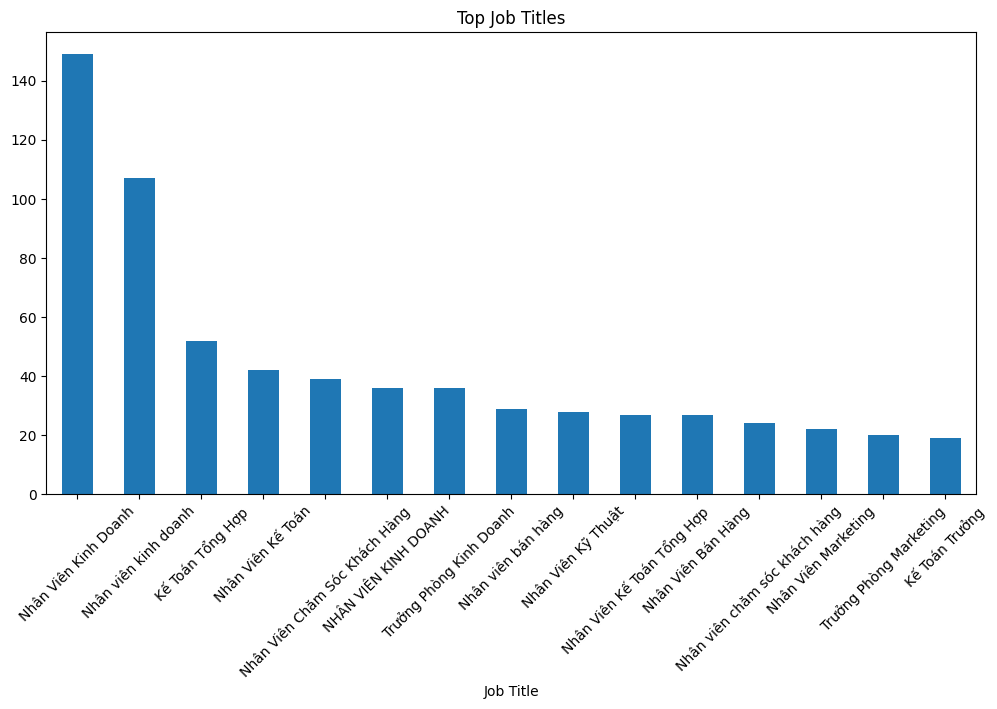

In [ ]:
plt.figure(figsize=(12,6))

job_df["Job Title"].value_counts().head(15).plot(kind="bar")

plt.title("Top Job Titles")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Merge User + CV

data = pd.merge(
    cv_df,
    user_df,
    on="UserID",
    how="left",
    suffixes=("_cv", "_user")
)

print(data.shape)

display(data.head())

(3983, 816)


,cv_id,URL User_cv,UserID,User Name_cv,Industry,Desired Job,Workplace Desired,Desired Salary,Gender_cv,Marriage_cv,...,Gender_user,Marriage_user,Age_user,URL User_user,crawled_email_user,crawled_phone_user,crawled_city_user,crawled_district_user,crawled_address_user,user_hash
0,0,https://timviec365.vn/ung-vien/nguyen-quan-uv9...,964496,Nguyễn Quân,Vận tải - Lái xe,Nhân viên lái xe bằng B2,Hà Nội,Thỏa thuận,Nam,Đã có gia đình,...,Nam,Đã có gia đình,36,https://timviec365.vn/ung-vien/nguyen-quan-uv9...,đăng nhập để xem email,đăng nhập để xem sdt,Hà Nội,Quận Ba Đình,"Quận Ba Đình, Hà Nội",U_423a0a06
1,1,https://timviec365.vn/ung-vien/nguyen-chau-uv9...,986206,Nguyễn Châu,Vận tải - Lái xe,Nhân viên lái xe bằng D,Bình Dương,Thỏa thuận,Nam,Đã có gia đình,...,Nam,Đã có gia đình,44,https://timviec365.vn/ung-vien/nguyen-chau-uv9...,đăng nhập để xem email,đăng nhập để xem sdt,Bình Dương,Thành phố Thuận An,"Thành phố Thuận An, Bình Dương",U_ce837033
2,2,https://timviec365.vn/ung-vien/la-thi-hoang-uv...,769632,LÃ THỊ HOÀNG,Hành chính - Văn phòng,"Nhân viên văn phòng, khu công nghiệp sử dụng t...",Bắc Giang,Thỏa thuận,Nữ,Độc thân,...,Nữ,Độc thân,25,https://timviec365.vn/ung-vien/la-thi-hoang-uv...,đăng nhập để xem email,đăng nhập để xem sdt,Lạng Sơn,Huyện Cao Lộc,Gia Cát - Cao Lộc - Lạng Sơn\t,U_f21884a9
3,3,https://timviec365.vn/ung-vien/nguyen-van-bao-...,981314,Nguyễn Văn Bảo,Vận tải - Lái xe,Nhân viên lái xe hạng C,Hà Nội,Thỏa thuận,Nam,Đã có gia đình,...,Nam,Đã có gia đình,33,https://timviec365.vn/ung-vien/nguyen-van-bao-...,đăng nhập để xem email,đăng nhập để xem sdt,Hà Nội,Quận Hà Đông,"Quận Hà Đông, thành phố Hà Nội",U_ebc0a4be
4,4,https://timviec365.vn/ung-vien/nguyen-thi-tu-u...,962892,Nguyễn Thị Tứ,Quản lý đơn hàng,Nhân viên thu mua,Hồ Chí Minh,Thỏa thuận,Nữ,Độc thân,...,Nữ,Độc thân,24,https://timviec365.vn/ung-vien/nguyen-thi-tu-u...,NaN,NaN,NaN,NaN,NaN,U_c4347468


In [ ]:
# ==========================
# KEEP IMPORTANT COLUMNS
# ==========================

cv_df = cv_df[
    [
        "cv_id",
        "UserID",
        "Industry",
        "Desired Job",
        "Workplace Desired",
        "Desired Salary"
    ]
]

job_df = job_df[
    [
        "job_id",
        "Job Title",
        "Name Company",
        "Company Address",
        "Job Description",
        "Job Requirements"
    ]
]

print(cv_df.head())
print(job_df.head())

   cv_id  UserID                Industry  \
0      0  964496        Vận tải - Lái xe   
1      1  986206        Vận tải - Lái xe   
2      2  769632  Hành chính - Văn phòng   
3      3  981314        Vận tải - Lái xe   
4      4  962892        Quản lý đơn hàng   

                                         Desired Job Workplace Desired  \
0                           Nhân viên lái xe bằng B2            Hà Nội   
1                            Nhân viên lái xe bằng D        Bình Dương   
2  Nhân viên văn phòng, khu công nghiệp sử dụng t...         Bắc Giang   
3                            Nhân viên lái xe hạng C            Hà Nội   
4                                  Nhân viên thu mua       Hồ Chí Minh   

  Desired Salary  
0     Thỏa thuận  
1     Thỏa thuận  
2     Thỏa thuận  
3     Thỏa thuận  
4     Thỏa thuận  
   job_id                                          Job Title  \
0       0                                 Sale Admin Website   
1       1  Thực Tập Sinh Lập Trình (No-Code, Low

In [ ]:
# ==========================
# HANDLE MISSING VALUE
# ==========================

cv_df = cv_df.fillna("")

job_df = job_df.fillna("")

print("CV Missing")
print(cv_df.isnull().sum())

print()

print("Job Missing")
print(job_df.isnull().sum())

CV Missing
cv_id                0
UserID               0
Industry             0
Desired Job          0
Workplace Desired    0
Desired Salary       0
dtype: int64

Job Missing
job_id              0
Job Title           0
Name Company        0
Company Address     0
Job Description     0
Job Requirements    0
dtype: int64


In [ ]:
# ==========================
# TEXT CLEANING
# ==========================

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z0-9 ]", " ", text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = nltk.word_tokenize(text)

    words = [w for w in words if w not in stop_words]

    text = " ".join(words)

    return text

In [ ]:
# ==========================
# CREATE CV TEXT
# ==========================

cv_df["CV_Text"] = (

    cv_df["Industry"] + " " +

    cv_df["Desired Job"] + " " +

    cv_df["Workplace Desired"] + " " +

    cv_df["Desired Salary"].astype(str)

)

cv_df["CV_Text"] = cv_df["CV_Text"].apply(clean_text)

display(cv_df[["CV_Text"]].head())

,CV_Text
0,v n l xe nh n vi n l xe b ng b2 h n th thu n
1,v n l xe nh n vi n l xe b ng b nh ng th thu n
2,h nh ch nh v n ph ng nh n vi n v n ph ng khu c...
3,v n l xe nh n vi n l xe h ng c h n th thu n
4,qu n l n h ng nh n vi n thu mua h ch minh th t...


In [ ]:
# ==========================
# CREATE JOB TEXT
# ==========================

job_df["Job_Text"] = (

    job_df["Job Title"] + " " +

    job_df["Job Description"] + " " +

    job_df["Job Requirements"]

)

job_df["Job_Text"] = job_df["Job_Text"].apply(clean_text)

display(job_df[["Job_Text"]].head())

,Job_Text
0,sale admin website th ng xuy n c p nh c c thay...
1,th c p sinh l p tr nh code low code platform p...
2,hr business partner x ng v th c hi n chi n l c...
3,general manager 1 l p v tri n khai k ho ch kin...
4,l n gymasaster qu n 12 tr c qu l n v n b n h n...


In [ ]:
print("CV")

display(cv_df[["CV_Text"]].sample(5))

print()

print("JOB")

display(job_df[["Job_Text"]].sample(5))

CV


,CV_Text
2407,v n l xe nh n vi n l xe ph xe b ng e h ch minh...
2031,h nh ch nh v n ph ng nh n vi n v n ph ng h ph ...
244,h nh ch nh v n ph ng nh n vi n v n ph ng ti ng...
1427,v n chuy n giao nh n nh n vi n kho ki k h ng h...
2851,v n l xe nh n vi n l xe b ng b2 h ch minh th t...



JOB


,Job_Text
38,gi vi n non gi ng ch c nu ng tr nontham gia c ...
6953,nh n vi n thi k thi k c c n ph c cty thi k ph ...
4812,nh n vi n th c c v n b n li u li n quan n c ng...
11682,qu n l kinh doanh x ng chi n l c v ki nh ng ng...
11645,th c p sinh net 1 nghi n c u li u chuy n n th ...


In [ ]:
# ==========================
# COMBINE ALL TEXT
# ==========================

all_documents = list(cv_df["CV_Text"])

all_documents.extend(job_df["Job_Text"])

print("Total Documents :", len(all_documents))

Total Documents : 18617


In [ ]:
# ==========================
# TF-IDF
# ==========================

tfidf = TfidfVectorizer(

    stop_words="english",

    max_features=8000

)

tfidf_matrix = tfidf.fit_transform(all_documents)

print(tfidf_matrix.shape)

(18617, 8000)


In [ ]:
# ==========================
# SPLIT VECTOR
# ==========================

cv_vectors = tfidf_matrix[:len(cv_df)]

job_vectors = tfidf_matrix[len(cv_df):]

print(cv_vectors.shape)
print(job_vectors.shape)

(3983, 8000)
(14634, 8000)


In [ ]:
# ==========================
# COSINE SIMILARITY
# ==========================

similarity_matrix = cosine_similarity(

    cv_vectors,

    job_vectors

)

print(similarity_matrix.shape)

(3983, 14634)


In [ ]:
similarity_matrix[:5,:5]

array([[0.16470925, 0.12122017, 0.18955107, 0.16885121, 0.15103688],
       [0.30731518, 0.22365136, 0.36739382, 0.32943311, 0.30242439],
       [0.54124424, 0.33812101, 0.55593656, 0.59223248, 0.5591495 ],
       [0.19717992, 0.14511744, 0.22691905, 0.20213843, 0.1808122 ],
       [0.22673348, 0.1732472 , 0.30668902, 0.32410608, 0.2768813 ]])

In [ ]:
# ==========================
# RECOMMEND TOP K JOBS
# ==========================

def recommend_jobs(cv_index, top_k=10):

    scores = similarity_matrix[cv_index]

    indices = np.argsort(scores)[::-1][:top_k]

    result = job_df.iloc[indices].copy()

    result["Similarity"] = scores[indices]

    return result

In [ ]:
recommend_jobs(0)

,job_id,Job Title,Name Company,Company Address,Job Description,Job Requirements,Job_Text,Similarity
8768,8768,Nhân Viên Lái Xe Văn Phòng (Bằng B2),Công ty TNHH phát triển đô thị và xây dựng 379,"15 Lê Văn Thiêm, Thanh Xuân, Hà Nội",Lái xe văn phòng chở CBNV và lãnh đạo theo yêu...,Bằng cấp lái xe B2;Kinh nghiệm lái xe văn phòn...,nh n vi n l xe v n ph ng b ng b2 l xe v n ph n...,0.748593
3852,3852,Nhân Viên Lái Xe Văn Phòng,Công ty TNHH PHD,"số 46 An Dương, Phường Yên Phụ, Quận Tây Hồ, H...",Lái xe văn phòng chở CBNV và lãnh đạo theo yêu...,Bằng cấp lái xe B2;Kinh nghiệm lái xe văn phòn...,nh n vi n l xe v n ph ng l xe v n ph ng ch cbn...,0.708478
3136,3136,Nhân Viên Lái Xe,Công Ty Cổ Phần Sơn Số 1 Việt Nam,"196/17 Cộng Hòa, P 12, Q Tân Bình, TP HCM",Lái xe văn phòng chở CBNV theo yêu cầu công vi...,Có các bằng cấp lái xe cần thiết theo yêu cầu;...,nh n vi n l xe l xe v n ph ng ch cbnv theo u c...,0.658760
11745,11745,NHÂN VIÊN CHĂM SÓC BẢO DƯỠNG XE,CÔNG TY CỔ PHẦN VIETWASH,"172 Hoa Lan, Phường 2, Quận Phú Nhuận, TPHCM","- Rửa xe, chăm sóc làm đẹp cho xe ô tô và xe m...",- Sức khỏe tốt - Giao tiếp nhanh nhẹn,nh n vi n ch c b ng xe r xe ch c l p cho xe v ...,0.656579
4985,4985,Tài Xế Xe Tải (Dấu B2),Công ty TNHH Elipsport,"1A Hoàng Trọng Mậu, KDC Him Lam, phường Tân Hư...","Vận chuyển Ghế massage, Máy chạy bộ, Xe đạp tậ...",Độ tuổi từ 25 trở lên Có kinh nghiệm 2 năm chạ...,x xe u b2 v n chuy n gh massage ch b xe p p kh...,0.651802
12539,12539,Thợ Rửa Xe,"công ty hệ thống rửa xe, chăm sóc xe t&n",789A Tỉnh Lộ 43. P. Tam Bình.Q Thủ Đức,Thợ rửa và chăm sóc xe hơi - xe máy. Yêu cầu k...,Có kinh nghiệm rửa xe và biết chạy xe ô tô. Là...,th r xe th r v ch c xe h xe u c u kinh nghi 1 ...,0.643355
9625,9625,Nhân Viên Lái Xe (Xe 4-7 Chỗ),Công ty CP DV - Giáo Dục Trí Đức,"5 Thoại Ngọc Hầu, P. Hòa Thạnh, Q. Tân Phú, TP...","Lái xe đưa đón theo yêu cầu, kịp thời và an to...","Nam dưới 40 tuổi, có hộ khẩu tại TP. HCM (ưu t...",nh n vi n l xe xe 4 7 ch l xe n theo u c u k p...,0.627977
11855,11855,"Cần tuyển 5 lái xe ,phụ xe làm tại Hà Nam",0398-092-263 Công Ty thương mại vận tải,hà nội xxxxxxx,Tuyển Lái Xe Tải Và Phụ Xe Giao Hàng Làm Ngay ...,THLV : 8h/ngày (quá giờ tính tăng ca) Nam từ 1...,c n tuy n 5 l xe ph xe l h nam tuy n l xe v ph...,0.621192
12079,12079,"Cần tuyển 7 lái xe ,phụ xe làm tại Hà Nam",0398-092-263 Công Ty thương mại vận tải,hà nội xxxxxxx,Tuyển Lái Xe Tải Và Phụ Xe Giao Hàng Làm Ngay ...,THLV : 8h/ngày (quá giờ tính tăng ca) Nam từ 1...,c n tuy n 7 l xe ph xe l h nam tuy n l xe v ph...,0.621192
14065,14065,Cần gấp 8 lái xe và phụ xe tại Lào caii,0398-092-263 Công Ty thương mại vận tải,hà nội xxxxxxx,Tuyển Lái Xe Tải Và Phụ Xe Giao Hàng Làm *****...,Chấp nhận bằng mới được bổ túc tay lái .• Khôn...,c n g p 8 l xe v ph xe l caii tuy n l xe v ph ...,0.618686


In [ ]:
# ==========================
# GROUND TRUTH
# ==========================

ground_truth = {}

for _, row in app_df.iterrows():

    jobs = []

    for i in range(10):

        col = f"job_{i}"

        if col in app_df.columns:

            if pd.notna(row[col]):

                jobs.append(row[col])

    ground_truth[row["cv_id"]] = jobs

print("Total CV:", len(ground_truth))

Total CV: 3983


In [ ]:
# ==========================
# PREDICTED JOB IDs
# ==========================

def recommend_job_ids(cv_index, top_k=10):

    scores = similarity_matrix[cv_index]

    idx = np.argsort(scores)[::-1][:top_k]

    return job_df.iloc[idx]["job_id"].tolist()

In [ ]:
# ==========================
# PRECISION@K
# ==========================

def precision_at_k(actual, predicted, k=10):

    predicted = predicted[:k]

    hit = len(set(actual) & set(predicted))

    return hit / k

In [ ]:
# ==========================
# RECALL@K
# ==========================

def recall_at_k(actual, predicted, k=10):

    predicted = predicted[:k]

    hit = len(set(actual) & set(predicted))

    if len(actual) == 0:

        return 0

    return hit / len(actual)

In [ ]:
# ==========================
# AVERAGE PRECISION
# ==========================

def average_precision(actual, predicted):

    score = 0.0

    hit = 0

    for i, p in enumerate(predicted):

        if p in actual:

            hit += 1

            score += hit / (i + 1)

    if hit == 0:

        return 0

    return score / len(actual)

In [ ]:
# ==========================
# MAP
# ==========================

def mean_average_precision(actual_dict):

    scores = []

    for i, cv in enumerate(cv_df["cv_id"]):

        if cv not in actual_dict:

            continue

        actual = actual_dict[cv]

        pred = recommend_job_ids(i)

        scores.append(

            average_precision(actual, pred)

        )

    return np.mean(scores)

In [ ]:
# ==========================
# NDCG
# ==========================

from math import log2

def ndcg(actual, predicted, k=10):

    dcg = 0

    for i, p in enumerate(predicted[:k]):

        if p in actual:

            dcg += 1 / log2(i + 2)

    idcg = 0

    m = min(len(actual), k)

    for i in range(m):

        idcg += 1 / log2(i + 2)

    if idcg == 0:

        return 0

    return dcg / idcg

In [ ]:
# ==========================
# EVALUATION
# ==========================

precision_scores = []

recall_scores = []

ndcg_scores = []

for i, cv in enumerate(cv_df["cv_id"]):

    if cv not in ground_truth:

        continue

    actual = ground_truth[cv]

    pred = recommend_job_ids(i)

    precision_scores.append(

        precision_at_k(actual, pred)

    )

    recall_scores.append(

        recall_at_k(actual, pred)

    )

    ndcg_scores.append(

        ndcg(actual, pred)

    )

print("="*50)

print("Precision@10 :", np.mean(precision_scores))

print("Recall@10 :", np.mean(recall_scores))

print("MAP :", mean_average_precision(ground_truth))

print("NDCG@10 :", np.mean(ndcg_scores))

print("="*50)

Precision@10 : 0.06482550841074568
Recall@10 : 0.06482550841074568
MAP : 0.035522777359332715
NDCG@10 : 0.08274133735894791


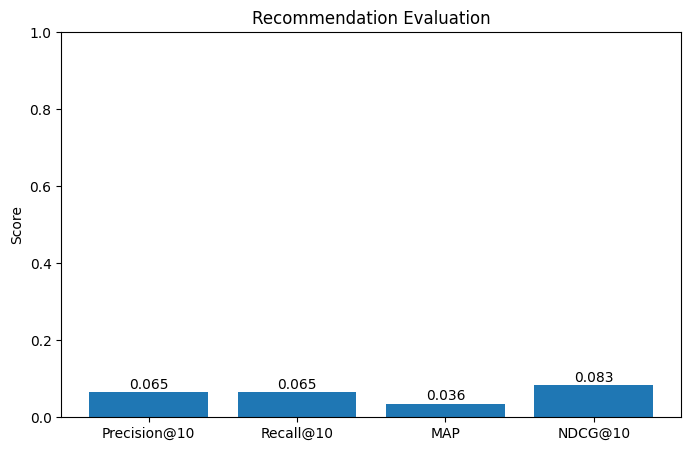

In [ ]:
metrics = {

    "Precision@10": np.mean(precision_scores),

    "Recall@10": np.mean(recall_scores),

    "MAP": mean_average_precision(ground_truth),

    "NDCG@10": np.mean(ndcg_scores)

}

plt.figure(figsize=(8,5))

plt.bar(metrics.keys(), metrics.values())

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Recommendation Evaluation")

for i, v in enumerate(metrics.values()):

    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.show()

In [ ]:
# ==========================
# TEST RECOMMENDATION
# ==========================

cv_index = 5

print("Student Information")

display(cv_df.iloc[[cv_index]])

print()

print("Recommended Jobs")

display(

    recommend_jobs(cv_index)

)

Student Information


,cv_id,UserID,Industry,Desired Job,Workplace Desired,Desired Salary,CV_Text
5,5,967782,Hành chính - Văn phòng,Nhân viên Hành Chính Nhân Sự,Bắc Giang,Thỏa thuận,h nh ch nh v n ph ng nh n vi n h nh ch nh nh n...



Recommended Jobs


,job_id,Job Title,Name Company,Company Address,Job Description,Job Requirements,Job_Text,Similarity
13812,13812,Công Nhân Vận Hành Máy Dệt,công ty CP dệt kim vinatex,Khu CN dệt may Phố nối - Hưng yên,Vận hành máy dệt,Vận hành máy dệt,c ng nh n v n h nh v n h nh v n h nh,0.732806
2452,2452,"Nhân Viên Kỹ Thuật Ngành Cửa Nhôm Kính, Cửa Cu...",Công Ty Cổ Phần Công Nghệ ACT WINDOW,"Số 193, Đường Kim Liên, Thành Phố Vinh , Tỉnh ...","- Sản xuất cửa, cắt kính theo yêu cầu của cấp ...",- Nam tốt nghiệp trung cấp trở lên.- Trung thự...,nh n vi n k thu ng nh c nh k nh c cu n th nh p...,0.667472
13361,13361,Trình dược viên,CÔNG TY TNHH DƯỢC PHẨM DRAGON,"Số 56, ngõ 139 Khương Thượng, P. Khương Thượng","Chịu trách nhiệm chăm sóc, bán hàng sản xuất Đ...",Nam/nữ,tr nh c vi n ch u tr ch nhi ch c b n h ng n xu...,0.664127
14458,14458,Thực Tập Sinh Hành Chính - Nhân Sự - Pháp Chế,TNHH Qt Data,"188 Đường Lê Trọng Tấn, Phường Hòa Phát, Quận ...",Thực Tập Sinh Hành Chính - Nhân Sự - Pháp Chế,- Có tránh nhiệm trong công việc -Có các kỹ nă...,th c p sinh h nh ch nh nh n ph p ch th c p sin...,0.662229
6234,6234,Dược Sĩ Bán Hàng Nhà Thuốc,Công ty Cổ phần Dược phẩm Vĩnh Phúc,"Số 777, Đường Mê Linh, P.Khai Quang, TP.Vĩnh Y...",- Bán thuốc theo đơn của bệnh nhân: Kiểm tra t...,Dược sĩ Trung cấp trở lên Có từ 1 năm kinh ngh...,c b n h ng nh thu c b n thu c theo n c b nh nh...,0.655408
8070,8070,Trưởng Nhóm Thu Hồi Nợ Tiền Giang,FE CREDIT,"Tầng trệt, 144 Cộng Hòa, P12, Q.Tân Bình, TP HCM.",- Quản lý hoạt động nhóm 12-15 nhân viên- Đảm ...,"- Tốt nghiệp Trung cấp trở lên, chuyên ngành L...",tr ng nh thu h n ti n giang qu n l ho ng nh 12...,0.649401
2443,2443,Chuyên Viên Kế Toán,Công ty cổ phần tập đoàn đầu tư Win Holdings,Tầng 10- Tòa Sunsquare- 21 Lê Đức Thọ- Nam Từ ...,"- Tổ chức, hướng dẫn thực hiện và kiểm tra các...",- Tốt nghiệp Đại học chuyên ngành Tài chính Kế...,chuy n vi n k n ch c h ng n th c hi n v ki tra...,0.634131
4136,4136,Nhân Viên Lễ Tân Bệnh Viện - Đi Làm Ngay,Công ty Cổ phần Y khoa HANO,"29 Hàn Thuyên, Hai Bà Trưng, Hà Nội",Thực hiện các thủ tục thanh toán viện phí cho ...,Giới tính: NữƯu tiên ứng viên có kinh nghiệm t...,nh n vi n l n b nh vi n l ngay th c hi n c c t...,0.618848
7358,7358,Kế Toán Viên Khu Vực Tiền Giang,Công ty Cổ phần Tex-Giang,"Lô BII-8, đường D3, KCN Tân Hương, huyện Châu ...",Nhập xuất nguyên phụ liệu.Thanh toán các chứng...,"Ứng xử trong giao tiếp lịch thiệp, hòa nhã.Tro...",k n vi n khu v c ti n giang nh p xu nguy n ph ...,0.617857
1461,1461,Thực Tập Sinh Hành Chính Nhân Sự,Công ty Cổ phần Sách Alpha - Chi nhánh HCM,"138C Nguyễn Đình Chiểu, Phường 6, Quận 3, TPHCM","• Thực hiện công tác hành chính , văn thư văn ...",• Sinh viên năm 3-4 chuyên ngành nhân sự hoặc ...,th c p sinh h nh ch nh nh n th c hi n c ng c h...,0.615011


In [ ]:
# Xuất kết quả

recommend_jobs(5).to_csv(

    "recommendation_result.csv",

    index=False

)

print("Saved Successfully!")

Saved Successfully!


In [ ]:
from google.colab import files

files.download("recommendation_result.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
job_df.head()

,job_id,Job Title,Name Company,Company Address,Job Description,Job Requirements,Job_Text
0,0,Sale Admin Website,Công ty Cổ phần Belie,"HN: Tầng 9, Tòa IDMC Mỹ Đình, 18 Tôn Thất Thuy...",Thường xuyên cập nhật các thay đổi liên quan t...,"1. Học vấn, kiến thức và trình độ chuyên môn:T...",sale admin website th ng xuy n c p nh c c thay...
1,1,"Thực Tập Sinh Lập Trình (No-Code, Low-Code Pla...",Công Ty Cổ Phần Global Online Branding,"Lầu 6, 235 Lý Thường Kiệt ,Phường 6 ,Quận Tân ...","Phối hợp với bộ phận lập trình No-code, Low-co...","Sinh viên năm 3, năm 4 hoặc sinh viên cao học ...",th c p sinh l p tr nh code low code platform p...
2,2,HR Business Partner,Công Ty Melody Logistics,"Số 01 Nguyễn Văn Đậu Phường 5, Quận Phú Nhuận,...",Xây dựng và thực hiện chiến lược nhân sự phù h...,Tốt nghiệp đại học các chuyên ngành liên quan ...,hr business partner x ng v th c hi n chi n l c...
3,3,General Manager,CÔNG TY TNHH DV HOLDINGS,"80 Đông Kinh Nghĩa Thục, Sơn Trà, Đà Nẵng",1. Lập và triển khai kế hoạch kinh doanh- Định...,- Tốt nghiệp đại học trở lên chuyên ngành quản...,general manager 1 l p v tri n khai k ho ch kin...
4,4,Lễ Tân Gymasaster Quận 12,CÔNG TY TNHH TM XNK NGUỒN SỐNG VIỆT,"235 đường 9A, khu dân cư Trung Sơn, huyện Bi...",- Trực quầy Lễ tân- Tư vấn bán hàng gói member...,- Giới tính: Ưu tiên Nữ từ 22 - 35 tuổi- Kinh ...,l n gymasaster qu n 12 tr c qu l n v n b n h n...


In [ ]:
# ==========================================
# RECOMMENDATION FUNCTION
# ==========================================

def recommend_jobs(cv_index, top_k=10):

    # Lấy similarity của CV với toàn bộ Job
    scores = similarity_matrix[cv_index]

    # Lấy vị trí của các Job có similarity cao nhất
    top_indices = np.argsort(scores)[::-1][:top_k]

    # Lấy thông tin Job
    result = job_df.iloc[top_indices].copy()

    # Thêm similarity score
    result["Similarity_Score"] = scores[top_indices]

    # Chuyển sang %
    result["Match_Percentage"] = (
        result["Similarity_Score"] * 100
    ).round(2)

    # Chỉ giữ các cột cần hiển thị
    result = result[
        [
            "job_id",
            "Job Title",
            "Name Company",
            "Company Address",
            "Match_Percentage"
        ]
    ]

    return result.reset_index(drop=True)

In [ ]:
# ==========================================
# TEST RECOMMENDATION
# ==========================================

cv_index = 0

print("THÔNG TIN CV")
display(
    cv_df.iloc[
        [cv_index]
    ][
        [
            "cv_id",
            "UserID",
            "Industry",
            "Desired Job",
            "Workplace Desired",
            "Desired Salary"
        ]
    ]
)

print("\nTOP 10 CÔNG VIỆC PHÙ HỢP")

recommend_result = recommend_jobs(
    cv_index,
    top_k=10
)

display(recommend_result)

THÔNG TIN CV


,cv_id,UserID,Industry,Desired Job,Workplace Desired,Desired Salary
0,0,964496,Vận tải - Lái xe,Nhân viên lái xe bằng B2,Hà Nội,Thỏa thuận



TOP 10 CÔNG VIỆC PHÙ HỢP


,job_id,Job Title,Name Company,Company Address,Match_Percentage
0,8768,Nhân Viên Lái Xe Văn Phòng (Bằng B2),Công ty TNHH phát triển đô thị và xây dựng 379,"15 Lê Văn Thiêm, Thanh Xuân, Hà Nội",74.86
1,3852,Nhân Viên Lái Xe Văn Phòng,Công ty TNHH PHD,"số 46 An Dương, Phường Yên Phụ, Quận Tây Hồ, H...",70.85
2,3136,Nhân Viên Lái Xe,Công Ty Cổ Phần Sơn Số 1 Việt Nam,"196/17 Cộng Hòa, P 12, Q Tân Bình, TP HCM",65.88
3,11745,NHÂN VIÊN CHĂM SÓC BẢO DƯỠNG XE,CÔNG TY CỔ PHẦN VIETWASH,"172 Hoa Lan, Phường 2, Quận Phú Nhuận, TPHCM",65.66
4,4985,Tài Xế Xe Tải (Dấu B2),Công ty TNHH Elipsport,"1A Hoàng Trọng Mậu, KDC Him Lam, phường Tân Hư...",65.18
5,12539,Thợ Rửa Xe,"công ty hệ thống rửa xe, chăm sóc xe t&n",789A Tỉnh Lộ 43. P. Tam Bình.Q Thủ Đức,64.34
6,9625,Nhân Viên Lái Xe (Xe 4-7 Chỗ),Công ty CP DV - Giáo Dục Trí Đức,"5 Thoại Ngọc Hầu, P. Hòa Thạnh, Q. Tân Phú, TP...",62.80
7,11855,"Cần tuyển 5 lái xe ,phụ xe làm tại Hà Nam",0398-092-263 Công Ty thương mại vận tải,hà nội xxxxxxx,62.12
8,12079,"Cần tuyển 7 lái xe ,phụ xe làm tại Hà Nam",0398-092-263 Công Ty thương mại vận tải,hà nội xxxxxxx,62.12
9,14065,Cần gấp 8 lái xe và phụ xe tại Lào caii,0398-092-263 Công Ty thương mại vận tải,hà nội xxxxxxx,61.87


In [ ]:
# ==========================================
# SEARCH CV BY CV_ID
# ==========================================

def recommend_by_cv_id(cv_id, top_k=10):

    matched = cv_df[
        cv_df["cv_id"] == cv_id
    ]

    if matched.empty:
        print("Không tìm thấy cv_id:", cv_id)
        return None

    cv_index = matched.index[0]

    print("CV ID:", cv_id)

    print("\nThông tin CV:")

    display(
        cv_df.loc[
            [cv_index],
            [
                "cv_id",
                "UserID",
                "Industry",
                "Desired Job",
                "Workplace Desired",
                "Desired Salary"
            ]
        ]
    )

    print("\nTOP", top_k, "CÔNG VIỆC PHÙ HỢP:")

    return recommend_jobs(
        cv_index,
        top_k
    )

In [ ]:
# Lấy một CV bất kỳ để test
test_cv_id = cv_df["cv_id"].iloc[0]

recommend_by_cv_id(
    test_cv_id,
    top_k=10
)

CV ID: 0

Thông tin CV:


,cv_id,UserID,Industry,Desired Job,Workplace Desired,Desired Salary
0,0,964496,Vận tải - Lái xe,Nhân viên lái xe bằng B2,Hà Nội,Thỏa thuận



TOP 10 CÔNG VIỆC PHÙ HỢP:


,job_id,Job Title,Name Company,Company Address,Match_Percentage
0,8768,Nhân Viên Lái Xe Văn Phòng (Bằng B2),Công ty TNHH phát triển đô thị và xây dựng 379,"15 Lê Văn Thiêm, Thanh Xuân, Hà Nội",74.86
1,3852,Nhân Viên Lái Xe Văn Phòng,Công ty TNHH PHD,"số 46 An Dương, Phường Yên Phụ, Quận Tây Hồ, H...",70.85
2,3136,Nhân Viên Lái Xe,Công Ty Cổ Phần Sơn Số 1 Việt Nam,"196/17 Cộng Hòa, P 12, Q Tân Bình, TP HCM",65.88
3,11745,NHÂN VIÊN CHĂM SÓC BẢO DƯỠNG XE,CÔNG TY CỔ PHẦN VIETWASH,"172 Hoa Lan, Phường 2, Quận Phú Nhuận, TPHCM",65.66
4,4985,Tài Xế Xe Tải (Dấu B2),Công ty TNHH Elipsport,"1A Hoàng Trọng Mậu, KDC Him Lam, phường Tân Hư...",65.18
5,12539,Thợ Rửa Xe,"công ty hệ thống rửa xe, chăm sóc xe t&n",789A Tỉnh Lộ 43. P. Tam Bình.Q Thủ Đức,64.34
6,9625,Nhân Viên Lái Xe (Xe 4-7 Chỗ),Công ty CP DV - Giáo Dục Trí Đức,"5 Thoại Ngọc Hầu, P. Hòa Thạnh, Q. Tân Phú, TP...",62.80
7,11855,"Cần tuyển 5 lái xe ,phụ xe làm tại Hà Nam",0398-092-263 Công Ty thương mại vận tải,hà nội xxxxxxx,62.12
8,12079,"Cần tuyển 7 lái xe ,phụ xe làm tại Hà Nam",0398-092-263 Công Ty thương mại vận tải,hà nội xxxxxxx,62.12
9,14065,Cần gấp 8 lái xe và phụ xe tại Lào caii,0398-092-263 Công Ty thương mại vận tải,hà nội xxxxxxx,61.87


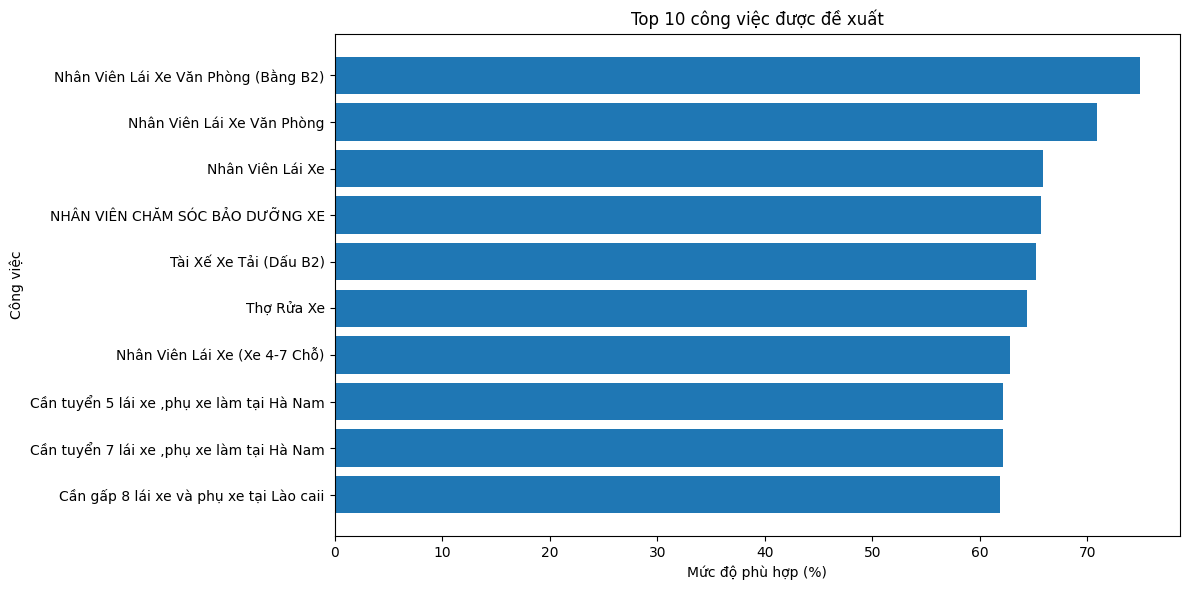

In [ ]:
# ==========================================
# TOP 10 RECOMMENDATION VISUALIZATION
# ==========================================

result = recommend_jobs(
    cv_index=0,
    top_k=10
)

plt.figure(figsize=(12, 6))

plt.barh(
    result["Job Title"].astype(str),
    result["Match_Percentage"]
)

plt.xlabel("Mức độ phù hợp (%)")
plt.ylabel("Công việc")
plt.title("Top 10 công việc được đề xuất")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================
# DISPLAY SCORES
# ==========================================

result[
    [
        "Job Title",
        "Name Company",
        "Match_Percentage"
    ]
]

,Job Title,Name Company,Match_Percentage
0,Nhân Viên Lái Xe Văn Phòng (Bằng B2),Công ty TNHH phát triển đô thị và xây dựng 379,74.86
1,Nhân Viên Lái Xe Văn Phòng,Công ty TNHH PHD,70.85
2,Nhân Viên Lái Xe,Công Ty Cổ Phần Sơn Số 1 Việt Nam,65.88
3,NHÂN VIÊN CHĂM SÓC BẢO DƯỠNG XE,CÔNG TY CỔ PHẦN VIETWASH,65.66
4,Tài Xế Xe Tải (Dấu B2),Công ty TNHH Elipsport,65.18
5,Thợ Rửa Xe,"công ty hệ thống rửa xe, chăm sóc xe t&n",64.34
6,Nhân Viên Lái Xe (Xe 4-7 Chỗ),Công ty CP DV - Giáo Dục Trí Đức,62.80
7,"Cần tuyển 5 lái xe ,phụ xe làm tại Hà Nam",0398-092-263 Công Ty thương mại vận tải,62.12
8,"Cần tuyển 7 lái xe ,phụ xe làm tại Hà Nam",0398-092-263 Công Ty thương mại vận tải,62.12
9,Cần gấp 8 lái xe và phụ xe tại Lào caii,0398-092-263 Công Ty thương mại vận tải,61.87


In [ ]:
# ==========================================
# TEST MULTIPLE CVS
# ==========================================

sample_size = min(5, len(cv_df))

sample_cv_indices = np.random.choice(
    len(cv_df),
    sample_size,
    replace=False
)

for idx in sample_cv_indices:

    print("=" * 80)

    print(
        "CV ID:",
        cv_df.iloc[idx]["cv_id"]
    )

    print(
        "Desired Job:",
        cv_df.iloc[idx]["Desired Job"]
    )

    print(
        "Industry:",
        cv_df.iloc[idx]["Industry"]
    )

    print("\nTop 5 Jobs:")

    display(
        recommend_jobs(
            idx,
            top_k=5
        )
    )

CV ID: 2308
Desired Job: Nhân viên lái xe hạng D
Industry: Vận tải - Lái xe

Top 5 Jobs:


,job_id,Job Title,Name Company,Company Address,Match_Percentage
0,11745,NHÂN VIÊN CHĂM SÓC BẢO DƯỠNG XE,CÔNG TY CỔ PHẦN VIETWASH,"172 Hoa Lan, Phường 2, Quận Phú Nhuận, TPHCM",61.73
1,3136,Nhân Viên Lái Xe,Công Ty Cổ Phần Sơn Số 1 Việt Nam,"196/17 Cộng Hòa, P 12, Q Tân Bình, TP HCM",61.36
2,12539,Thợ Rửa Xe,"công ty hệ thống rửa xe, chăm sóc xe t&n",789A Tỉnh Lộ 43. P. Tam Bình.Q Thủ Đức,60.67
3,3852,Nhân Viên Lái Xe Văn Phòng,Công ty TNHH PHD,"số 46 An Dương, Phường Yên Phụ, Quận Tây Hồ, H...",59.88
4,9625,Nhân Viên Lái Xe (Xe 4-7 Chỗ),Công ty CP DV - Giáo Dục Trí Đức,"5 Thoại Ngọc Hầu, P. Hòa Thạnh, Q. Tân Phú, TP...",58.83


CV ID: 3358
Desired Job: Thực tập sinh IT Phân cứng
Industry: IT Phần cứng - mạng

Top 5 Jobs:


,job_id,Job Title,Name Company,Company Address,Match_Percentage
0,12747,Thực tập sinh nhân sự,công ty cổ phần tư vấn hip việt nam,"Số 17 Lô Tt02, Ngõ 2, P. Hàm Nghi, Mỹ Đình, Từ...",66.70
1,1513,Thực Tập Sinh Nghiên Cứu Thị Trường,Công ty TNHH Primehome,"Tầng 10 Tòa nhà VTC Online Building, Số 18 Tam...",66.28
2,2345,Kế Toán Viên,CHI NHÁNH CÔNG TY CỔ PHẦN TẬP ĐOÀN HIPT (TP.HÀ...,"5 Nguyễn Gia Thiều, Phường Võ Thị Sáu, Quận 3,...",66.25
3,2823,Thực Tập Sinh Kế Toán (Có Hỗ Trợ Lương Và Dấu ...,CÔNG TY TNHH TƯ VẤN QUẢN TRỊ DOANH NGHIỆP CATAX,"Số 3 ngõ 560 Ngô Gia Tự, Phường Đức Giang, Quậ...",65.92
4,9642,Chuyên Viên Phát Triển Hệ Thống Phân Phối,CHIS VIỆT NAM,"102 TRƯỜNG CHINH, HÀ NỘI",65.35


CV ID: 2813
Desired Job: Nhân viên lái xe, phụ xe - Bằng Lái Xe Hạng C
Industry: Vận tải - Lái xe

Top 5 Jobs:


,job_id,Job Title,Name Company,Company Address,Match_Percentage
0,11745,NHÂN VIÊN CHĂM SÓC BẢO DƯỠNG XE,CÔNG TY CỔ PHẦN VIETWASH,"172 Hoa Lan, Phường 2, Quận Phú Nhuận, TPHCM",70.92
1,3136,Nhân Viên Lái Xe,Công Ty Cổ Phần Sơn Số 1 Việt Nam,"196/17 Cộng Hòa, P 12, Q Tân Bình, TP HCM",70.36
2,12539,Thợ Rửa Xe,"công ty hệ thống rửa xe, chăm sóc xe t&n",789A Tỉnh Lộ 43. P. Tam Bình.Q Thủ Đức,69.61
3,3852,Nhân Viên Lái Xe Văn Phòng,Công ty TNHH PHD,"số 46 An Dương, Phường Yên Phụ, Quận Tây Hồ, H...",69.55
4,8768,Nhân Viên Lái Xe Văn Phòng (Bằng B2),Công ty TNHH phát triển đô thị và xây dựng 379,"15 Lê Văn Thiêm, Thanh Xuân, Hà Nội",67.37


CV ID: 2989
Desired Job: nhân viên
Industry: Công nghệ cao

Top 5 Jobs:


,job_id,Job Title,Name Company,Company Address,Match_Percentage
0,12550,Nhân viên Sale,TẬP ĐOÀN TAIPEI 101 GRUOP,Toà nhà Taipei 101 (Sát cửa khẩu Mộc Bài - giá...,74.65
1,12516,"Thợ mộc, nhựa , nhôm , lao động phổ thông",Cửa Hàng Đồ Gỗ Cũ Cương Hằng,163 Đại Mỗ,69.27
2,10645,02 phụ bếp,Cow Mee Inn-mỳ bò Đài Loan,"15D Ngô Quang Huy,Thảo Điền,quận 2",68.42
3,12253,Nhân viên kinh doanh,Công Ty TNHH Mỹ Phẩm Nội Địa Nhật,320 Trường Chinh,66.63
4,10859,Nhân viên sale,Công Ty TNHH Mình Châu,320,65.87


CV ID: 3280
Desired Job: Nhân viên văn phòng
Industry: Hành chính - Văn phòng

Top 5 Jobs:


,job_id,Job Title,Name Company,Company Address,Match_Percentage
0,12550,Nhân viên Sale,TẬP ĐOÀN TAIPEI 101 GRUOP,Toà nhà Taipei 101 (Sát cửa khẩu Mộc Bài - giá...,76.30
1,12516,"Thợ mộc, nhựa , nhôm , lao động phổ thông",Cửa Hàng Đồ Gỗ Cũ Cương Hằng,163 Đại Mỗ,75.04
2,10645,02 phụ bếp,Cow Mee Inn-mỳ bò Đài Loan,"15D Ngô Quang Huy,Thảo Điền,quận 2",72.47
3,14161,THỢ ĐIỆN,Lien Minh Group,"1k Yersin, phường 10, Tp Đà Lạt",71.73
4,13969,Nhân viên phục vụ,Lien Minh Group,"1k Yersin, phường 10, Tp Đà Lạt",69.32


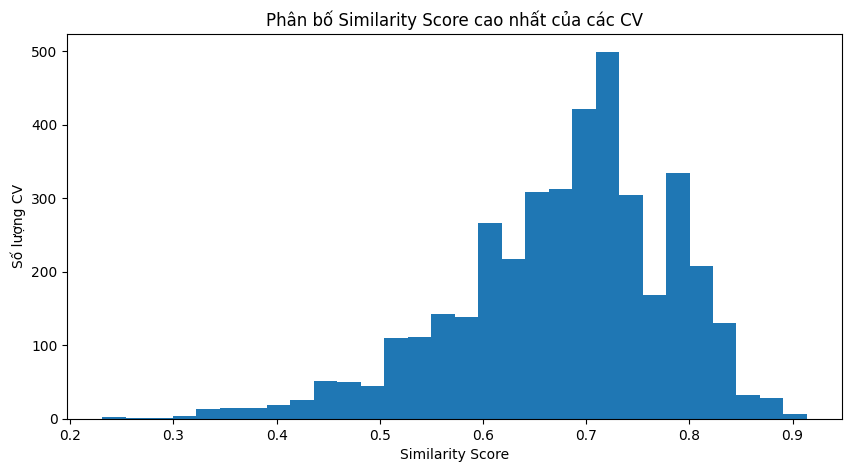

In [ ]:
# ==========================================
# SIMILARITY SCORE DISTRIBUTION
# ==========================================

top_scores = []

for i in range(len(cv_df)):

    scores = similarity_matrix[i]

    top_score = np.max(scores)

    top_scores.append(top_score)

plt.figure(figsize=(10, 5))

plt.hist(
    top_scores,
    bins=30
)

plt.xlabel("Similarity Score")

plt.ylabel("Số lượng CV")

plt.title(
    "Phân bố Similarity Score cao nhất của các CV"
)

plt.show()

In [ ]:
# ==========================================
# SIMILARITY STATISTICS
# ==========================================

similarity_stats = pd.Series(
    top_scores
).describe()

display(similarity_stats)

,0
count,3983.000000
mean,0.678520
std,0.103477
min,0.231145
25%,0.617626
50%,0.696059
75%,0.748593
max,0.913879


In [ ]:
# ==========================================
# MOST RECOMMENDED JOBS
# ==========================================

recommendation_counter = {}

for i in range(len(cv_df)):

    scores = similarity_matrix[i]

    top_indices = np.argsort(scores)[::-1][:10]

    for idx in top_indices:

        job_id = job_df.iloc[idx]["job_id"]

        recommendation_counter[job_id] = (
            recommendation_counter.get(job_id, 0) + 1
        )

recommendation_df = pd.DataFrame(
    recommendation_counter.items(),
    columns=[
        "job_id",
        "Recommendation_Count"
    ]
)

recommendation_df = recommendation_df.sort_values(
    "Recommendation_Count",
    ascending=False
)

display(
    recommendation_df.head(10)
)

,job_id,Recommendation_Count
1,3852,1869
2,3136,1856
0,8768,1806
3,11745,1805
6,9625,1776
5,12539,1374
10,5111,1235
4,4985,1230
11,7219,1054
8,12079,1007


In [ ]:
# ==========================================
# ADD JOB INFORMATION
# ==========================================

recommendation_df = recommendation_df.merge(
    job_df[
        [
            "job_id",
            "Job Title",
            "Name Company"
        ]
    ],
    on="job_id",
    how="left"
)

display(
    recommendation_df.head(10)
)

,job_id,Recommendation_Count,Job Title,Name Company
0,3852,1869,Nhân Viên Lái Xe Văn Phòng,Công ty TNHH PHD
1,3136,1856,Nhân Viên Lái Xe,Công Ty Cổ Phần Sơn Số 1 Việt Nam
2,8768,1806,Nhân Viên Lái Xe Văn Phòng (Bằng B2),Công ty TNHH phát triển đô thị và xây dựng 379
3,11745,1805,NHÂN VIÊN CHĂM SÓC BẢO DƯỠNG XE,CÔNG TY CỔ PHẦN VIETWASH
4,9625,1776,Nhân Viên Lái Xe (Xe 4-7 Chỗ),Công ty CP DV - Giáo Dục Trí Đức
5,12539,1374,Thợ Rửa Xe,"công ty hệ thống rửa xe, chăm sóc xe t&n"
6,5111,1235,Nhân Viên Kỹ Thuật Sửa Chữa Ô Tô,CÔNG TY TNHH TM Ô TÔ HOÀNG LONG
7,4985,1230,Tài Xế Xe Tải (Dấu B2),Công ty TNHH Elipsport
8,7219,1054,Quản Lý Và Điều Hành Xe,Công ty Cổ phần Panel Việt
9,12079,1007,"Cần tuyển 7 lái xe ,phụ xe làm tại Hà Nam",0398-092-263 Công Ty thương mại vận tải


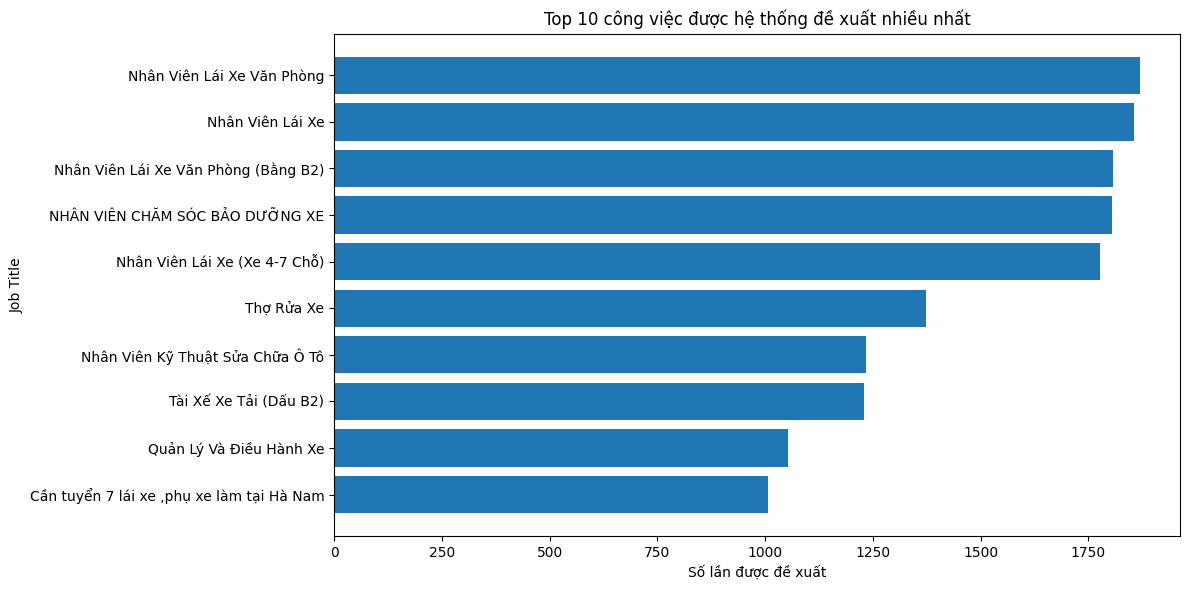

In [ ]:
# ==========================================
# MOST RECOMMENDED JOBS CHART
# ==========================================

top_recommended = recommendation_df.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top_recommended["Job Title"].astype(str),
    top_recommended["Recommendation_Count"]
)

plt.xlabel("Số lần được đề xuất")

plt.ylabel("Job Title")

plt.title(
    "Top 10 công việc được hệ thống đề xuất nhiều nhất"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================
# SAVE TF-IDF MODEL
# ==========================================

import joblib

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print(
    "Đã lưu TF-IDF Vectorizer:"
)

print(
    "tfidf_vectorizer.pkl"
)

Đã lưu TF-IDF Vectorizer:
tfidf_vectorizer.pkl


In [ ]:
# ==========================================
# SAVE VECTORS
# ==========================================

from scipy.sparse import save_npz

save_npz(
    "cv_vectors.npz",
    cv_vectors
)

save_npz(
    "job_vectors.npz",
    job_vectors
)

print("Đã lưu CV vectors và Job vectors.")

Đã lưu CV vectors và Job vectors.


In [ ]:
# ==========================================
# SAVE JOB DATA
# ==========================================

job_df.to_csv(
    "processed_job_data.csv",
    index=False,
    encoding="utf-8-sig"
)

cv_df.to_csv(
    "processed_cv_data.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu dữ liệu đã xử lý.")

Đã lưu dữ liệu đã xử lý.


In [ ]:
# ==========================================
# FINAL RECOMMENDATION FUNCTION
# ==========================================

def get_job_recommendations(cv_id, top_k=10):

    # Tìm CV
    matched_cv = cv_df[
        cv_df["cv_id"] == cv_id
    ]

    if matched_cv.empty:

        return pd.DataFrame({
            "Error": [
                f"Không tìm thấy CV ID: {cv_id}"
            ]
        })

    # Lấy index
    cv_index = matched_cv.index[0]

    # Tính similarity
    scores = similarity_matrix[cv_index]

    # Top K
    top_indices = np.argsort(
        scores
    )[::-1][:top_k]

    # Kết quả
    result = job_df.iloc[
        top_indices
    ].copy()

    result[
        "Similarity_Score"
    ] = scores[top_indices]

    result[
        "Match_Percentage"
    ] = (
        result["Similarity_Score"] * 100
    ).round(2)

    result = result[
        [
            "job_id",
            "Job Title",
            "Name Company",
            "Company Address",
            "Match_Percentage"
        ]
    ]

    return result.reset_index(
        drop=True
    )

In [ ]:
# ==========================================
# FINAL TEST
# ==========================================

test_cv = cv_df["cv_id"].iloc[0]

result = get_job_recommendations(
    test_cv,
    top_k=10
)

display(result)

,job_id,Job Title,Name Company,Company Address,Match_Percentage
0,8768,Nhân Viên Lái Xe Văn Phòng (Bằng B2),Công ty TNHH phát triển đô thị và xây dựng 379,"15 Lê Văn Thiêm, Thanh Xuân, Hà Nội",74.86
1,3852,Nhân Viên Lái Xe Văn Phòng,Công ty TNHH PHD,"số 46 An Dương, Phường Yên Phụ, Quận Tây Hồ, H...",70.85
2,3136,Nhân Viên Lái Xe,Công Ty Cổ Phần Sơn Số 1 Việt Nam,"196/17 Cộng Hòa, P 12, Q Tân Bình, TP HCM",65.88
3,11745,NHÂN VIÊN CHĂM SÓC BẢO DƯỠNG XE,CÔNG TY CỔ PHẦN VIETWASH,"172 Hoa Lan, Phường 2, Quận Phú Nhuận, TPHCM",65.66
4,4985,Tài Xế Xe Tải (Dấu B2),Công ty TNHH Elipsport,"1A Hoàng Trọng Mậu, KDC Him Lam, phường Tân Hư...",65.18
5,12539,Thợ Rửa Xe,"công ty hệ thống rửa xe, chăm sóc xe t&n",789A Tỉnh Lộ 43. P. Tam Bình.Q Thủ Đức,64.34
6,9625,Nhân Viên Lái Xe (Xe 4-7 Chỗ),Công ty CP DV - Giáo Dục Trí Đức,"5 Thoại Ngọc Hầu, P. Hòa Thạnh, Q. Tân Phú, TP...",62.80
7,11855,"Cần tuyển 5 lái xe ,phụ xe làm tại Hà Nam",0398-092-263 Công Ty thương mại vận tải,hà nội xxxxxxx,62.12
8,12079,"Cần tuyển 7 lái xe ,phụ xe làm tại Hà Nam",0398-092-263 Công Ty thương mại vận tải,hà nội xxxxxxx,62.12
9,14065,Cần gấp 8 lái xe và phụ xe tại Lào caii,0398-092-263 Công Ty thương mại vận tải,hà nội xxxxxxx,61.87


In [ ]:
# ==========================================
# CHECK JOB ID STRUCTURE
# ==========================================

print("Các cột của job_data:")
print(job_df.columns.tolist())

print("\nThông tin JobID nếu tồn tại:")

if "JobID" in job_df.columns:
    print(job_df["JobID"].head(20).tolist())
    print("\nSố lượng JobID duy nhất:",
          job_df["JobID"].nunique())

    print("\nKiểu dữ liệu:")
    print(job_df["JobID"].dtype)

else:
    print("Không tồn tại cột JobID")

Các cột của job_data:
['job_id', 'Job Title', 'Name Company', 'Company Address', 'Job Description', 'Job Requirements', 'Job_Text']

Thông tin JobID nếu tồn tại:
Không tồn tại cột JobID


In [ ]:
# ==========================================
# CHECK APPLICATION JOB IDs
# ==========================================

job_columns = [
    col for col in app_df.columns
    if str(col).startswith("job_")
]

print("Các cột Job trong applications:")
print(job_columns)

print("\nSố lượng cột Job:", len(job_columns))

display(
    app_df[job_columns].head()
)

Các cột Job trong applications:
['job_0', 'job_1', 'job_2', 'job_3', 'job_4', 'job_5', 'job_6', 'job_7', 'job_8', 'job_9']

Số lượng cột Job: 10


,job_0,job_1,job_2,job_3,job_4,job_5,job_6,job_7,job_8,job_9
0,8768,3633,3981,13370,7478,11622,3852,7219,4985,6828
1,13259,13985,13119,10869,11562,12170,3633,13370,12961,13248
2,12340,6587,2304,13712,9731,10561,12594,1005,1291,8813
3,3633,8768,13370,11891,3981,8707,10068,6828,4985,13985
4,2146,13652,6004,12136,5991,14288,2077,10124,14237,3409


In [ ]:
# ==========================================
# COLLECT APPLICATION JOB IDs
# ==========================================

application_job_ids = set()

for col in job_columns:

    values = app_df[col].dropna()

    for value in values:

        application_job_ids.add(
            str(value).strip()
        )

print(
    "Số lượng Job ID khác nhau trong applications:",
    len(application_job_ids)
)

print(
    "Một số Job ID:",
    list(application_job_ids)[:20]
)

Số lượng Job ID khác nhau trong applications: 2460
Một số Job ID: ['9290', '14275', '12539', '4615', '3282', '12066', '1840', '4039', '9277', '6840', '788', '12961', '1868', '2019', '6134', '2912', '12628', '10503', '423', '13324']


In [ ]:
# ==========================================
# CHECK JOBID MATCH
# ==========================================

if "JobID" in job_df.columns:

    job_ids = set(
        job_df["JobID"]
        .dropna()
        .astype(str)
        .str.strip()
    )

    matched_ids = (
        application_job_ids
        & job_ids
    )

    print(
        "Job ID trong applications:",
        len(application_job_ids)
    )

    print(
        "Job ID trong job_data:",
        len(job_ids)
    )

    print(
        "Job ID khớp:",
        len(matched_ids)
    )

    print(
        "Tỷ lệ khớp:",
        round(
            len(matched_ids)
            / len(application_job_ids)
            * 100,
            2
        ),
        "%"
    )

In [ ]:
# ==========================================
# CELL 50 - KIỂM TRA ID CỦA JOB
# ==========================================

print("Các cột hiện tại của job_df:")
print(job_df.columns.tolist())

print("\n5 dòng đầu:")
display(job_df.head())

Các cột hiện tại của job_df:
['job_id', 'Job Title', 'Name Company', 'Company Address', 'Job Description', 'Job Requirements', 'Job_Text']

5 dòng đầu:


,job_id,Job Title,Name Company,Company Address,Job Description,Job Requirements,Job_Text
0,0,Sale Admin Website,Công ty Cổ phần Belie,"HN: Tầng 9, Tòa IDMC Mỹ Đình, 18 Tôn Thất Thuy...",Thường xuyên cập nhật các thay đổi liên quan t...,"1. Học vấn, kiến thức và trình độ chuyên môn:T...",sale admin website th ng xuy n c p nh c c thay...
1,1,"Thực Tập Sinh Lập Trình (No-Code, Low-Code Pla...",Công Ty Cổ Phần Global Online Branding,"Lầu 6, 235 Lý Thường Kiệt ,Phường 6 ,Quận Tân ...","Phối hợp với bộ phận lập trình No-code, Low-co...","Sinh viên năm 3, năm 4 hoặc sinh viên cao học ...",th c p sinh l p tr nh code low code platform p...
2,2,HR Business Partner,Công Ty Melody Logistics,"Số 01 Nguyễn Văn Đậu Phường 5, Quận Phú Nhuận,...",Xây dựng và thực hiện chiến lược nhân sự phù h...,Tốt nghiệp đại học các chuyên ngành liên quan ...,hr business partner x ng v th c hi n chi n l c...
3,3,General Manager,CÔNG TY TNHH DV HOLDINGS,"80 Đông Kinh Nghĩa Thục, Sơn Trà, Đà Nẵng",1. Lập và triển khai kế hoạch kinh doanh- Định...,- Tốt nghiệp đại học trở lên chuyên ngành quản...,general manager 1 l p v tri n khai k ho ch kin...
4,4,Lễ Tân Gymasaster Quận 12,CÔNG TY TNHH TM XNK NGUỒN SỐNG VIỆT,"235 đường 9A, khu dân cư Trung Sơn, huyện Bi...",- Trực quầy Lễ tân- Tư vấn bán hàng gói member...,- Giới tính: Ưu tiên Nữ từ 22 - 35 tuổi- Kinh ...,l n gymasaster qu n 12 tr c qu l n v n b n h n...


In [ ]:
# ==========================================
# CELL 51 - KIỂM TRA APPLICATIONS
# ==========================================

print("Các cột applications:")
print(app_df.columns.tolist())

job_columns = [
    col for col in app_df.columns
    if str(col).startswith("job_")
]

print("\nCác cột job:")
print(job_columns)

display(app_df[job_columns].head())

Các cột applications:
['application_id', 'cv_id', 'job_0', 'dist_0', 'job_1', 'dist_1', 'job_2', 'dist_2', 'job_3', 'dist_3', 'job_4', 'dist_4', 'job_5', 'dist_5', 'job_6', 'dist_6', 'job_7', 'dist_7', 'job_8', 'dist_8', 'job_9', 'dist_9']

Các cột job:
['job_0', 'job_1', 'job_2', 'job_3', 'job_4', 'job_5', 'job_6', 'job_7', 'job_8', 'job_9']


,job_0,job_1,job_2,job_3,job_4,job_5,job_6,job_7,job_8,job_9
0,8768,3633,3981,13370,7478,11622,3852,7219,4985,6828
1,13259,13985,13119,10869,11562,12170,3633,13370,12961,13248
2,12340,6587,2304,13712,9731,10561,12594,1005,1291,8813
3,3633,8768,13370,11891,3981,8707,10068,6828,4985,13985
4,2146,13652,6004,12136,5991,14288,2077,10124,14237,3409


In [ ]:
# ==========================================
# CELL 52 - KIỂM TRA MAPPING
# ==========================================

# ID hiện tại của job_data
job_ids = set(
    job_df["job_id"]
    .dropna()
    .astype(str)
    .str.strip()
)

# ID trong applications
application_job_ids = set()

for col in job_columns:

    values = (
        app_df[col]
        .dropna()
        .astype(str)
        .str.strip()
    )

    application_job_ids.update(values)

# ID giao nhau
matched_ids = (
    application_job_ids
    & job_ids
)

print("Số Job ID trong job_data:",
      len(job_ids))

print("Số Job ID trong applications:",
      len(application_job_ids))

print("Số ID khớp:",
      len(matched_ids))

if len(application_job_ids) > 0:

    match_rate = (
        len(matched_ids)
        / len(application_job_ids)
        * 100
    )

    print(
        f"Tỷ lệ khớp: {match_rate:.2f}%"
    )

Số Job ID trong job_data: 14634
Số Job ID trong applications: 2460
Số ID khớp: 2460
Tỷ lệ khớp: 100.00%


In [ ]:
print(job_df.columns.tolist())
print(app_df.columns.tolist())

print("\nJOB:")
display(job_df.head(3))

print("\nAPPLICATION:")
display(app_df.head(3))

['job_id', 'Job Title', 'Name Company', 'Company Address', 'Job Description', 'Job Requirements', 'Job_Text']
['application_id', 'cv_id', 'job_0', 'dist_0', 'job_1', 'dist_1', 'job_2', 'dist_2', 'job_3', 'dist_3', 'job_4', 'dist_4', 'job_5', 'dist_5', 'job_6', 'dist_6', 'job_7', 'dist_7', 'job_8', 'dist_8', 'job_9', 'dist_9']

JOB:


,job_id,Job Title,Name Company,Company Address,Job Description,Job Requirements,Job_Text
0,0,Sale Admin Website,Công ty Cổ phần Belie,"HN: Tầng 9, Tòa IDMC Mỹ Đình, 18 Tôn Thất Thuy...",Thường xuyên cập nhật các thay đổi liên quan t...,"1. Học vấn, kiến thức và trình độ chuyên môn:T...",sale admin website th ng xuy n c p nh c c thay...
1,1,"Thực Tập Sinh Lập Trình (No-Code, Low-Code Pla...",Công Ty Cổ Phần Global Online Branding,"Lầu 6, 235 Lý Thường Kiệt ,Phường 6 ,Quận Tân ...","Phối hợp với bộ phận lập trình No-code, Low-co...","Sinh viên năm 3, năm 4 hoặc sinh viên cao học ...",th c p sinh l p tr nh code low code platform p...
2,2,HR Business Partner,Công Ty Melody Logistics,"Số 01 Nguyễn Văn Đậu Phường 5, Quận Phú Nhuận,...",Xây dựng và thực hiện chiến lược nhân sự phù h...,Tốt nghiệp đại học các chuyên ngành liên quan ...,hr business partner x ng v th c hi n chi n l c...



APPLICATION:


,application_id,cv_id,job_0,dist_0,job_1,dist_1,job_2,dist_2,job_3,dist_3,...,job_5,dist_5,job_6,dist_6,job_7,dist_7,job_8,dist_8,job_9,dist_9
0,0,0,8768,0.0,3633,0.00,3981,0.00,13370,0.00,...,11622,0.00,3852,0.00,7219,0.00,4985,607.65,6828,607.65
1,1,1,13259,0.0,13985,23.25,13119,23.25,10869,23.25,...,12170,23.25,3633,1120.62,13370,1120.62,12961,1120.62,13248,1120.62
2,2,2,12340,NaN,6587,NaN,2304,NaN,13712,NaN,...,10561,NaN,12594,NaN,1005,NaN,1291,NaN,8813,NaN


In [ ]:
print("JOB DATA")
print("Rows:", len(job_df))
print("Min job_id:", job_df["job_id"].min())
print("Max job_id:", job_df["job_id"].max())

print("\nAPPLICATION JOB")
print(
    app_df[job_columns]
    .min()
    .min()
)

print(
    app_df[job_columns]
    .max()
    .max()
)

JOB DATA
Rows: 14634
Min job_id: 0
Max job_id: 14633

APPLICATION JOB
16
14628


In [ ]:
print("\nCV ID range")

print(
    cv_df["cv_id"].min(),
    cv_df["cv_id"].max()
)


CV ID range
0 3982


In [ ]:
# ==========================================
# CELL 50 - CHUẨN HÓA JOB ID
# ==========================================

job_df["job_id"] = pd.to_numeric(
    job_df["job_id"],
    errors="coerce"
).astype("Int64")

for col in job_columns:
    app_df[col] = pd.to_numeric(
        app_df[col],
        errors="coerce"
    ).astype("Int64")

print("Job ID range:")
print(
    job_df["job_id"].min(),
    "->",
    job_df["job_id"].max()
)

print("\nApplication Job ID range:")

app_values = pd.concat(
    [
        app_df[col]
        for col in job_columns
    ]
).dropna()

print(
    app_values.min(),
    "->",
    app_values.max()
)

Job ID range:
0 -> 14633

Application Job ID range:
16 -> 14628


In [ ]:
# ==========================================
# CELL 51 - CHECK JOB ID MATCH
# ==========================================

job_ids = set(
    job_df["job_id"]
    .dropna()
    .astype(int)
)

application_job_ids = set(
    app_values.astype(int)
)

matched_ids = (
    application_job_ids
    & job_ids
)

print(
    "Số Job ID trong job_data:",
    len(job_ids)
)

print(
    "Số Job ID trong applications:",
    len(application_job_ids)
)

print(
    "Số Job ID khớp:",
    len(matched_ids)
)

match_rate = (
    len(matched_ids)
    / len(application_job_ids)
    * 100
)

print(
    f"Tỷ lệ khớp: {match_rate:.2f}%"
)

Số Job ID trong job_data: 14634
Số Job ID trong applications: 2460
Số Job ID khớp: 2460
Tỷ lệ khớp: 100.00%


In [ ]:
# ==========================================
# CELL 52 - CREATE GROUND TRUTH
# ==========================================

ground_truth = {}

for _, row in app_df.iterrows():

    cv_id = row["cv_id"]

    relevant_jobs = []

    for col in job_columns:

        value = row[col]

        if pd.notna(value):

            relevant_jobs.append(
                int(value)
            )

    ground_truth[
        int(cv_id)
    ] = relevant_jobs

print(
    "Số CV có ground truth:",
    len(ground_truth)
)

# Xem thử
first_cv = list(ground_truth.keys())[0]

print(
    "CV:",
    first_cv
)

print(
    "Relevant jobs:",
    ground_truth[first_cv]
)

Số CV có ground truth: 3983
CV: 0
Relevant jobs: [8768, 3633, 3981, 13370, 7478, 11622, 3852, 7219, 4985, 6828]


In [ ]:
# ==========================================
# CELL 53 - GET PREDICTED JOBS
# ==========================================

def get_predicted_job_ids(
    cv_index,
    top_k=10
):

    scores = similarity_matrix[
        cv_index
    ]

    top_indices = np.argsort(
        scores
    )[::-1][:top_k]

    predicted_job_ids = (
        job_df.iloc[
            top_indices
        ]["job_id"]
        .astype(int)
        .tolist()
    )

    return predicted_job_ids

In [ ]:
# ==========================================
# CELL 54 - PRECISION@10
# ==========================================

def precision_at_k(
    actual,
    predicted,
    k=10
):

    predicted = predicted[:k]

    if len(predicted) == 0:
        return 0

    hits = len(
        set(actual)
        & set(predicted)
    )

    return hits / len(predicted)

In [ ]:
# ==========================================
# CELL 55 - RECALL@10
# ==========================================

def recall_at_k(
    actual,
    predicted,
    k=10
):

    if len(actual) == 0:
        return 0

    predicted = predicted[:k]

    hits = len(
        set(actual)
        & set(predicted)
    )

    return hits / len(actual)

In [ ]:
# ==========================================
# CELL 56 - AVERAGE PRECISION @10
# ==========================================

def average_precision_at_k(
    actual,
    predicted,
    k=10
):

    actual = set(actual)

    predicted = predicted[:k]

    if len(actual) == 0:
        return 0

    score = 0
    hits = 0

    for i, job_id in enumerate(
        predicted
    ):

        if job_id in actual:

            hits += 1

            precision = (
                hits / (i + 1)
            )

            score += precision

    if hits == 0:
        return 0

    return score / min(
        len(actual),
        k
    )

In [ ]:
# ==========================================
# CELL 57 - NDCG@10
# ==========================================

def ndcg_at_k(
    actual,
    predicted,
    k=10
):

    actual = set(actual)

    predicted = predicted[:k]

    dcg = 0

    for i, job_id in enumerate(
        predicted
    ):

        if job_id in actual:

            dcg += (
                1 /
                np.log2(i + 2)
            )

    ideal_hits = min(
        len(actual),
        k
    )

    if ideal_hits == 0:
        return 0

    idcg = sum(
        1 /
        np.log2(i + 2)
        for i in range(ideal_hits)
    )

    return dcg / idcg

In [ ]:
# ==========================================
# CELL 58 - MODEL EVALUATION
# ==========================================

evaluation_results = []

# Map CV ID -> DataFrame index
cv_id_to_index = {
    int(cv_id): index
    for index, cv_id
    in enumerate(cv_df["cv_id"])
}

for cv_id, actual in ground_truth.items():

    if cv_id not in cv_id_to_index:
        continue

    cv_index = cv_id_to_index[
        cv_id
    ]

    predicted = get_predicted_job_ids(
        cv_index,
        top_k=10
    )

    p10 = precision_at_k(
        actual,
        predicted,
        10
    )

    r10 = recall_at_k(
        actual,
        predicted,
        10
    )

    ap10 = average_precision_at_k(
        actual,
        predicted,
        10
    )

    ndcg10 = ndcg_at_k(
        actual,
        predicted,
        10
    )

    evaluation_results.append({

        "cv_id": cv_id,

        "Precision@10": p10,

        "Recall@10": r10,

        "AP@10": ap10,

        "NDCG@10": ndcg10

    })

evaluation_df = pd.DataFrame(
    evaluation_results
)

print(
    "Số CV được đánh giá:",
    len(evaluation_df)
)

display(
    evaluation_df.head(10)
)

Số CV được đánh giá: 3983


,cv_id,Precision@10,Recall@10,AP@10,NDCG@10
0,0,0.3,0.3,0.260000,0.444097
1,1,0.0,0.0,0.000000,0.000000
2,2,0.0,0.0,0.000000,0.000000
3,3,0.2,0.2,0.045000,0.154574
4,4,0.0,0.0,0.000000,0.000000
5,5,0.0,0.0,0.000000,0.000000
6,6,0.2,0.2,0.166667,0.330138
7,7,0.2,0.2,0.166667,0.330138
8,8,0.0,0.0,0.000000,0.000000
9,9,0.0,0.0,0.000000,0.000000


In [ ]:
# ==========================================
# CELL 59 - FINAL METRICS
# ==========================================

final_metrics = pd.DataFrame({

    "Metric": [
        "Precision@10",
        "Recall@10",
        "MAP@10",
        "NDCG@10"
    ],

    "Score": [

        evaluation_df[
            "Precision@10"
        ].mean(),

        evaluation_df[
            "Recall@10"
        ].mean(),

        evaluation_df[
            "AP@10"
        ].mean(),

        evaluation_df[
            "NDCG@10"
        ].mean()

    ]

})

display(final_metrics)

,Metric,Score
0,Precision@10,0.064826
1,Recall@10,0.064826
2,MAP@10,0.035523
3,NDCG@10,0.082741


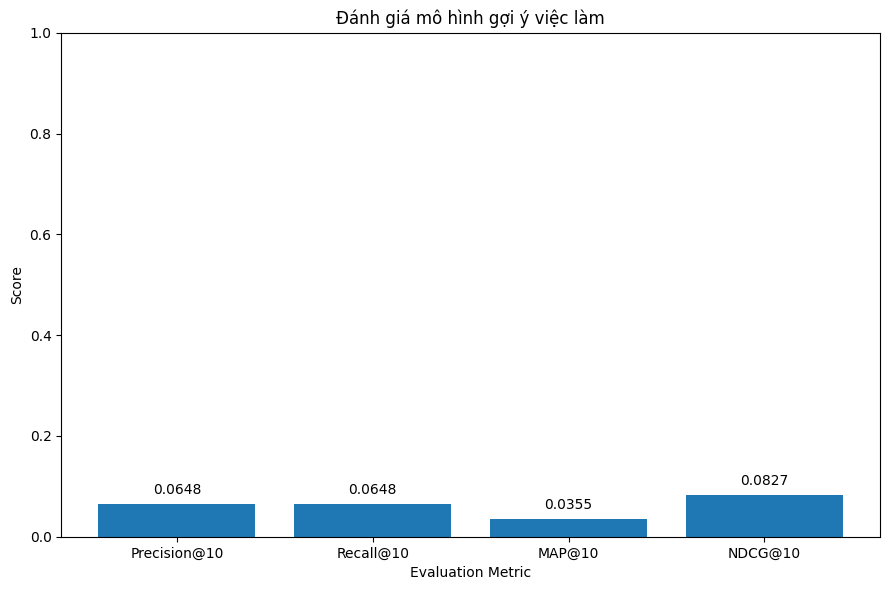

In [ ]:
# ==========================================
# CELL 60 - EVALUATION CHART
# ==========================================

plt.figure(
    figsize=(9, 6)
)

bars = plt.bar(
    final_metrics["Metric"],
    final_metrics["Score"]
)

plt.ylim(0, 1)

plt.xlabel("Evaluation Metric")

plt.ylabel("Score")

plt.title(
    "Đánh giá mô hình gợi ý việc làm"
)

for bar, value in zip(
    bars,
    final_metrics["Score"]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        value + 0.02,

        f"{value:.4f}",

        ha="center"
    )

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================
# CELL 61 - SAVE EVALUATION
# ==========================================

evaluation_df.to_csv(
    "evaluation_results.csv",
    index=False,
    encoding="utf-8-sig"
)

final_metrics.to_csv(
    "final_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Đã lưu evaluation_results.csv"
)

print(
    "Đã lưu final_metrics.csv"
)

Đã lưu evaluation_results.csv
Đã lưu final_metrics.csv


In [ ]:
# ==========================================
# CELL 62 - GENERATE ALL RECOMMENDATIONS
# ==========================================

all_recommendations = []

for cv_index in range(len(cv_df)):

    cv_id = int(cv_df.iloc[cv_index]["cv_id"])

    scores = similarity_matrix[cv_index]

    top_indices = np.argsort(scores)[::-1][:10]

    for rank, job_index in enumerate(top_indices, start=1):

        all_recommendations.append({
            "cv_id": cv_id,
            "Rank": rank,
            "job_id": int(job_df.iloc[job_index]["job_id"]),
            "Job Title": job_df.iloc[job_index]["Job Title"],
            "Name Company": job_df.iloc[job_index]["Name Company"],
            "Similarity_Score": round(float(scores[job_index]), 4),
            "Match_Percentage": round(float(scores[job_index]) * 100, 2)
        })

all_recommendations_df = pd.DataFrame(all_recommendations)

print("Kích thước kết quả:")
print(all_recommendations_df.shape)

display(all_recommendations_df.head(20))

Kích thước kết quả:
(39830, 7)


,cv_id,Rank,job_id,Job Title,Name Company,Similarity_Score,Match_Percentage
0,0,1,8768,Nhân Viên Lái Xe Văn Phòng (Bằng B2),Công ty TNHH phát triển đô thị và xây dựng 379,0.7486,74.86
1,0,2,3852,Nhân Viên Lái Xe Văn Phòng,Công ty TNHH PHD,0.7085,70.85
2,0,3,3136,Nhân Viên Lái Xe,Công Ty Cổ Phần Sơn Số 1 Việt Nam,0.6588,65.88
3,0,4,11745,NHÂN VIÊN CHĂM SÓC BẢO DƯỠNG XE,CÔNG TY CỔ PHẦN VIETWASH,0.6566,65.66
4,0,5,4985,Tài Xế Xe Tải (Dấu B2),Công ty TNHH Elipsport,0.6518,65.18
5,0,6,12539,Thợ Rửa Xe,"công ty hệ thống rửa xe, chăm sóc xe t&n",0.6434,64.34
6,0,7,9625,Nhân Viên Lái Xe (Xe 4-7 Chỗ),Công ty CP DV - Giáo Dục Trí Đức,0.6280,62.80
7,0,8,11855,"Cần tuyển 5 lái xe ,phụ xe làm tại Hà Nam",0398-092-263 Công Ty thương mại vận tải,0.6212,62.12
8,0,9,12079,"Cần tuyển 7 lái xe ,phụ xe làm tại Hà Nam",0398-092-263 Công Ty thương mại vận tải,0.6212,62.12
9,0,10,14065,Cần gấp 8 lái xe và phụ xe tại Lào caii,0398-092-263 Công Ty thương mại vận tải,0.6187,61.87


In [ ]:
# ==========================================
# CELL 63 - SAVE ALL RECOMMENDATIONS
# ==========================================

all_recommendations_df.to_csv(
    "all_job_recommendations.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu: all_job_recommendations.csv")

Đã lưu: all_job_recommendations.csv


In [ ]:
# ==========================================
# CELL 64 - VIEW ONE CV RECOMMENDATION
# ==========================================

test_cv_id = 0

print("THÔNG TIN CV:")

display(
    cv_df[
        cv_df["cv_id"] == test_cv_id
    ]
)

print("\nTOP 10 CÔNG VIỆC ĐƯỢC GỢI Ý:")

display(
    all_recommendations_df[
        all_recommendations_df["cv_id"] == test_cv_id
    ]
)

THÔNG TIN CV:


,cv_id,UserID,Industry,Desired Job,Workplace Desired,Desired Salary,CV_Text
0,0,964496,Vận tải - Lái xe,Nhân viên lái xe bằng B2,Hà Nội,Thỏa thuận,v n l xe nh n vi n l xe b ng b2 h n th thu n



TOP 10 CÔNG VIỆC ĐƯỢC GỢI Ý:


,cv_id,Rank,job_id,Job Title,Name Company,Similarity_Score,Match_Percentage
0,0,1,8768,Nhân Viên Lái Xe Văn Phòng (Bằng B2),Công ty TNHH phát triển đô thị và xây dựng 379,0.7486,74.86
1,0,2,3852,Nhân Viên Lái Xe Văn Phòng,Công ty TNHH PHD,0.7085,70.85
2,0,3,3136,Nhân Viên Lái Xe,Công Ty Cổ Phần Sơn Số 1 Việt Nam,0.6588,65.88
3,0,4,11745,NHÂN VIÊN CHĂM SÓC BẢO DƯỠNG XE,CÔNG TY CỔ PHẦN VIETWASH,0.6566,65.66
4,0,5,4985,Tài Xế Xe Tải (Dấu B2),Công ty TNHH Elipsport,0.6518,65.18
5,0,6,12539,Thợ Rửa Xe,"công ty hệ thống rửa xe, chăm sóc xe t&n",0.6434,64.34
6,0,7,9625,Nhân Viên Lái Xe (Xe 4-7 Chỗ),Công ty CP DV - Giáo Dục Trí Đức,0.6280,62.80
7,0,8,11855,"Cần tuyển 5 lái xe ,phụ xe làm tại Hà Nam",0398-092-263 Công Ty thương mại vận tải,0.6212,62.12
8,0,9,12079,"Cần tuyển 7 lái xe ,phụ xe làm tại Hà Nam",0398-092-263 Công Ty thương mại vận tải,0.6212,62.12
9,0,10,14065,Cần gấp 8 lái xe và phụ xe tại Lào caii,0398-092-263 Công Ty thương mại vận tải,0.6187,61.87


In [ ]:
# ==========================================
# CELL 65 - RECOMMEND BY CV ID
# ==========================================

def show_recommendations(cv_id):

    cv_id = int(cv_id)

    cv_info = cv_df[
        cv_df["cv_id"] == cv_id
    ]

    if cv_info.empty:
        print("Không tìm thấy CV ID:", cv_id)
        return

    print("===== THÔNG TIN CV =====")

    display(cv_info)

    print("===== TOP 10 JOB RECOMMENDATIONS =====")

    recommendations = all_recommendations_df[
        all_recommendations_df["cv_id"] == cv_id
    ]

    display(recommendations)

In [ ]:
show_recommendations(0)

===== THÔNG TIN CV =====


,cv_id,UserID,Industry,Desired Job,Workplace Desired,Desired Salary,CV_Text
0,0,964496,Vận tải - Lái xe,Nhân viên lái xe bằng B2,Hà Nội,Thỏa thuận,v n l xe nh n vi n l xe b ng b2 h n th thu n


===== TOP 10 JOB RECOMMENDATIONS =====


,cv_id,Rank,job_id,Job Title,Name Company,Similarity_Score,Match_Percentage
0,0,1,8768,Nhân Viên Lái Xe Văn Phòng (Bằng B2),Công ty TNHH phát triển đô thị và xây dựng 379,0.7486,74.86
1,0,2,3852,Nhân Viên Lái Xe Văn Phòng,Công ty TNHH PHD,0.7085,70.85
2,0,3,3136,Nhân Viên Lái Xe,Công Ty Cổ Phần Sơn Số 1 Việt Nam,0.6588,65.88
3,0,4,11745,NHÂN VIÊN CHĂM SÓC BẢO DƯỠNG XE,CÔNG TY CỔ PHẦN VIETWASH,0.6566,65.66
4,0,5,4985,Tài Xế Xe Tải (Dấu B2),Công ty TNHH Elipsport,0.6518,65.18
5,0,6,12539,Thợ Rửa Xe,"công ty hệ thống rửa xe, chăm sóc xe t&n",0.6434,64.34
6,0,7,9625,Nhân Viên Lái Xe (Xe 4-7 Chỗ),Công ty CP DV - Giáo Dục Trí Đức,0.6280,62.80
7,0,8,11855,"Cần tuyển 5 lái xe ,phụ xe làm tại Hà Nam",0398-092-263 Công Ty thương mại vận tải,0.6212,62.12
8,0,9,12079,"Cần tuyển 7 lái xe ,phụ xe làm tại Hà Nam",0398-092-263 Công Ty thương mại vận tải,0.6212,62.12
9,0,10,14065,Cần gấp 8 lái xe và phụ xe tại Lào caii,0398-092-263 Công Ty thương mại vận tải,0.6187,61.87


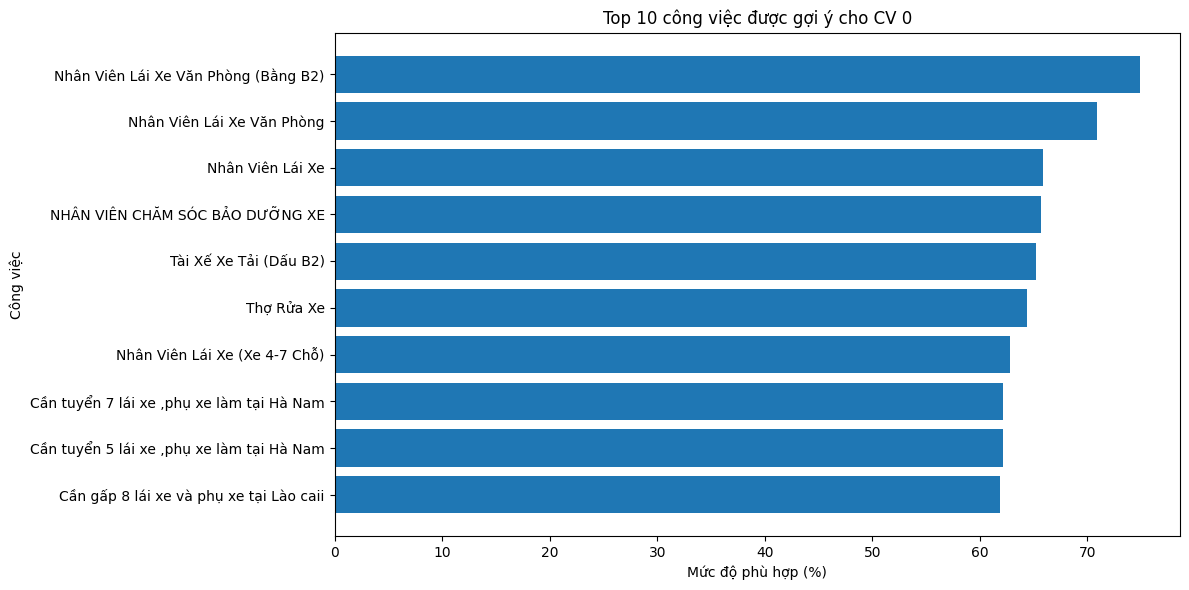

In [ ]:
# ==========================================
# CELL 66 - TOP 10 VISUALIZATION
# ==========================================

test_cv_id = 0

plot_data = all_recommendations_df[
    all_recommendations_df["cv_id"] == test_cv_id
].sort_values(
    "Match_Percentage",
    ascending=True
)

plt.figure(figsize=(12, 6))

plt.barh(
    plot_data["Job Title"].astype(str),
    plot_data["Match_Percentage"]
)

plt.xlabel("Mức độ phù hợp (%)")
plt.ylabel("Công việc")

plt.title(
    f"Top 10 công việc được gợi ý cho CV {test_cv_id}"
)

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================
# CELL 67 - FINAL EXPERIMENT RESULTS
# ==========================================

print("===== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH =====")

display(final_metrics)

print("\nSố CV được đánh giá:", len(evaluation_df))

print("\nSố CV trong dataset:", len(cv_df))

print("\nSố lượng Job:", len(job_df))

print("\nTổng số gợi ý được tạo:")
print(len(all_recommendations_df))

===== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH =====


,Metric,Score
0,Precision@10,0.064826
1,Recall@10,0.064826
2,MAP@10,0.035523
3,NDCG@10,0.082741



Số CV được đánh giá: 3983

Số CV trong dataset: 3983

Số lượng Job: 14634

Tổng số gợi ý được tạo:
39830
